# PIA and PIVA for 3-Compartment Prostate MRI

This notebook is organised as a controlled experiment.

**Question:** given 16 noisy MRI measurements per voxel, can we recover the
hidden 3-compartment tissue parameters?

Each voxel has:

- 3 diffusivities: `D_ep`, `D_st`, `D_lu`
- 3 relaxation times: `T2_ep`, `T2_st`, `T2_lu`
- 3 volume fractions: `v_ep`, `v_st`, `v_lu`

The core inverse problem is:

$$X_{noisy}(b,TE) \rightarrow (D, T2, v)$$

Classical **NLLS** solves this by direct curve fitting. PIA and PIVA learn an
encoder, but keep the decoder as the fixed MRI physics equation.

## Experimental Flow

| Stage | Purpose |
|---|---|
| 1. Motivation | show why NLLS becomes unstable under noisy MRI signals |
| 2. Data generation | create biologically plausible patient-level synthetic data |
| 3. NLLS baseline | fit the model directly and inspect actual vs predicted parameters |
| 4. PIA | train a deterministic physics-informed autoencoder and evaluate it |
| 5. PIVA | train a variational version and evaluate uncertainty-aware predictions |
| 6. Final comparison | compare NLLS, PIA, and PIVA on the same held-out cohort |

## Strategy

The notebook separates the experiment into three model families.

1. **NLLS baseline**  
   Uses `scipy.curve_fit` independently for each voxel. It is transparent and
   classical, but unstable when noisy signals make many parameter combinations
   produce similar curves.

2. **PIA**  
   A neural encoder predicts `(D, T2, v)`. The decoder is not learned; it is the
   fixed MRI signal equation. Training minimises clean-signal reconstruction error.

3. **PIVA**  
   A variational version of PIA. Instead of a single deterministic latent code,
   it learns a posterior distribution and can produce uncertainty estimates.

The same held-out synthetic cohort is used for all evaluations, so the comparisons
are apples-to-apples.

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
# numpy          → numerical simulation and vectorised physics model
# scipy          → curve_fit (the classical NLLS baseline)
# matplotlib     → all plots

import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# b-values (ms/mm²) and TE values (ms) — same as the PIA repo
B_VALS  = [0, 150, 1000, 1500]    # 4 b-values
TE_VALS = [0,  13,   93,  143]    # 4 echo times
N_SIGNALS = len(B_VALS) * len(TE_VALS)  # = 16 signals per voxel

# Flattened b-TE grid: shape (16,) each — used throughout
b_grid  = np.array([[b]*len(TE_VALS) for b in B_VALS], dtype=float).ravel()   # (16,)
te_grid = np.array(TE_VALS * len(B_VALS), dtype=float)                        # (16,)
b_TE_flat = np.vstack([b_grid, te_grid])  # (2, 16) — for scipy curve_fit interface

# Global plot style
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})
print(f"✓ Imports done  |  Signals per voxel: {N_SIGNALS}  ({len(B_VALS)} b-vals × {len(TE_VALS)} TEs)")


✓ Imports done  |  Signals per voxel: 16  (4 b-vals × 4 TEs)


---
## 1. Motivation — Why NLLS Breaks Down

The 3-compartment model is biologically meaningful but numerically fragile.
Per voxel, the model tries to recover 9 latent parameters from only 16 measured
signal values.

At high SNR, NLLS may find a reasonable solution. At clinical noise levels, the
inverse problem becomes ill-conditioned: many different `(D, T2, v)` combinations
can reconstruct almost the same noisy signal. That is why the notebook first tests
NLLS directly before introducing PIA or PIVA.

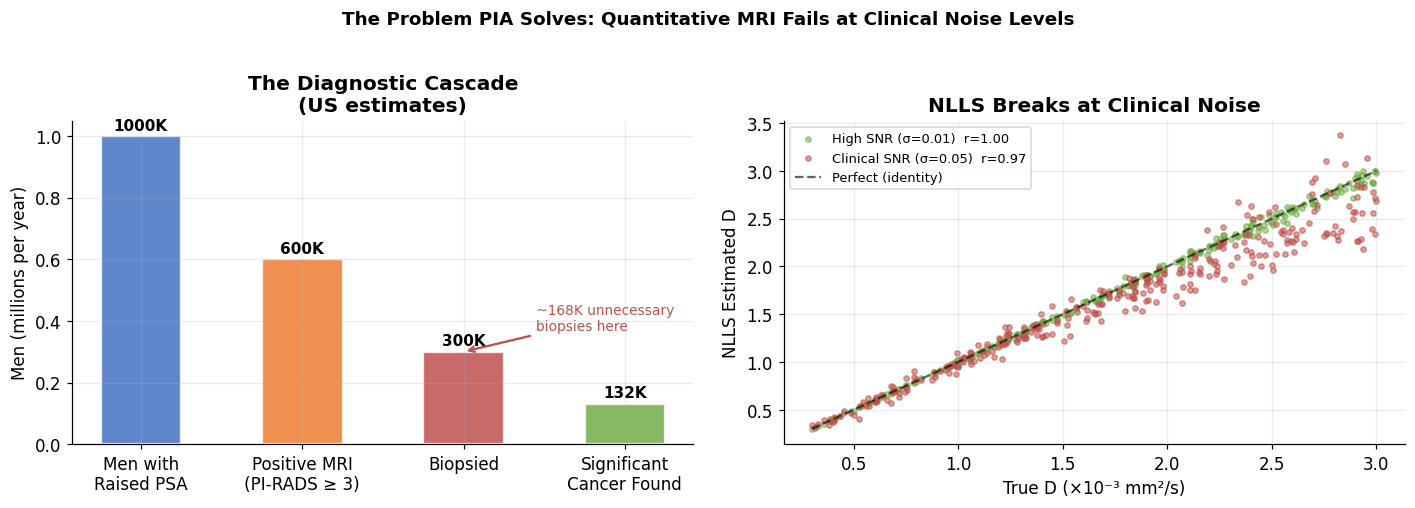

In [4]:
# ── Dramatise the clinical problem with two charts ────────────────────────────
# Left:  The false-positive cascade — how many men are biopsied unnecessarily
# Right: What NLLS failure looks like — estimated D vs true D at two SNR levels
#        (monoexponential model used here for simplicity)

def monoexp_signal_flat(b_TE, D, T2):
    """
    Monoexponential signal model for NLLS curve_fit.
    b_TE : (2, N) array — first row b-values, second row TE values
    D    : scalar diffusivity (×10⁻³ mm²/s)
    T2   : scalar T2 relaxation time (ms)
    """
    b, TE = b_TE
    return np.exp(-b / 1000 * D) * np.exp(-TE / T2)

# Vectorised version: (N_vox,) D/T2 → (N_vox, 16) signals
def monoexp_batch(D_arr, T2_arr):
    # D_arr: (N,)  T2_arr: (N,)  →  output: (N, 16)
    D_col  = D_arr[:, None]    # (N, 1)
    T2_col = T2_arr[:, None]   # (N, 1)
    b_row  = b_grid[None, :]   # (1, 16)
    te_row = te_grid[None, :]  # (1, 16)
    return np.exp(-b_row / 1000 * D_col) * np.exp(-te_row / T2_col)  # (N, 16)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: biopsy cascade ──────────────────────────────────────────────────────
ax = axes[0]
stages = ['Men with\nRaised PSA', 'Positive MRI\n(PI-RADS ≥ 3)', 'Biopsied', 'Significant\nCancer Found']
counts = [1_000_000, 600_000, 300_000, 132_000]
colors = ['#4472C4', '#ED7D31', '#C0504D', '#70AD47']

bars = ax.bar(stages, [c / 1e6 for c in counts], color=colors, alpha=0.85,
              width=0.5, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Men (millions per year)')
ax.set_title('The Diagnostic Cascade\n(US estimates)', fontweight='bold')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{count // 1000}K', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.annotate('~168K unnecessary\nbiopsies here',
            xy=(2, counts[2] / 1e6), xytext=(2.45, 0.37),
            fontsize=9, color='#C0504D',
            arrowprops=dict(arrowstyle='->', color='#C0504D', lw=1.5))

# ── Right: NLLS failure at two SNR levels ────────────────────────────────────
ax = axes[1]
rng = np.random.default_rng(99)
N_MC = 300
D_true_mc  = rng.uniform(0.3, 3.0, N_MC)
T2_true_mc = rng.uniform(20, 750, N_MC)
S_clean_mc = monoexp_batch(D_true_mc, T2_true_mc)  # (300, 16)

for sigma, label, color in [(0.01, 'High SNR (σ=0.01)', '#70AD47'),
                             (0.05, 'Clinical SNR (σ=0.05)', '#C0504D')]:
    e1 = rng.normal(0, sigma, S_clean_mc.shape)
    e2 = rng.normal(0, sigma, S_clean_mc.shape)
    S_noisy = np.sqrt((S_clean_mc + e1)**2 + e2**2)

    D_est = []
    for i in range(N_MC):
        try:
            popt, _ = curve_fit(monoexp_signal_flat, b_TE_flat, S_noisy[i],
                                p0=[1.5, 100], bounds=([0.01, 1], [5, 1000]))
            D_est.append(popt[0])
        except Exception:
            D_est.append(np.nan)
    D_est = np.array(D_est)
    valid = ~np.isnan(D_est)
    r = pearsonr(D_true_mc[valid], D_est[valid])[0]
    ax.scatter(D_true_mc[valid], D_est[valid], s=12, alpha=0.55, color=color,
               label=f'{label}  r={r:.2f}')

ax.plot([0.3, 3], [0.3, 3], 'k--', linewidth=1.5, alpha=0.6, label='Perfect (identity)')
ax.set_xlabel('True D (×10⁻³ mm²/s)'); ax.set_ylabel('NLLS Estimated D')
ax.set_title('NLLS Breaks at Clinical Noise', fontweight='bold')
ax.legend(fontsize=8.5)

plt.suptitle('The Problem PIA Solves: Quantitative MRI Fails at Clinical Noise Levels',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## 2. Data Generation — Biologically Plausible Synthetic Patients

This section creates the synthetic cohort used by all later models.

The hierarchy is:

```text
patient phenotype
  -> patient-level D/T2 centres
  -> voxel-level D/T2/v values
  -> clean 16-channel MRI signal
  -> Rician noisy training input
```

The important correction is that `D` and `T2` are now generated around each
patient's own centre rather than drawing the full physiological range and then
shifting it again.

In [5]:
# ── Data generation: patient-level bootstrapped 3-compartment cohort ────────────
# Generates a synthetic prostate MRI cohort with patient-level biological variation.
#
# Data structure:
#   • N_PATIENTS independent patients, each with VOXELS_PER_PATIENT voxels.
#   • Patient-level phenotype drawn from a Dirichlet prior on compartment composition.
#   • Patient-level D/T2 centres are shifted from population means.
#   • Voxel-level D and T2 vary around each patient's own centre.
#   • Clean physics signals computed by pia3_signal_np() (vectorised decoder).
#   • Augmentation applies clinically plausible Rician magnitude noise.

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

COMP_NAMES   = ["epithelium", "stroma", "lumen"]
N_COMP       = 3
SIGNAL_SCALE = 1000.0  # signals are stored at 1000× unit scale

# Rician noise is specified on unit-scale S0. The default range below gives
# S0-level SNR from roughly 100:1 to 12.5:1, avoiding unrealistic 1000+ spikes.
CLINICAL_NOISE_SIGMA_RANGE = (0.01, 0.08)

# Physiological priors matching the original PIA implementation
D_MEAN_3   = np.array([0.5,  1.2,   2.85 ], dtype=np.float32)   # mean D per compartment (×10⁻³ mm²/s)
T2_MEAN_3  = np.array([45.0, 70.0,  750.0 ], dtype=np.float32)   # mean T2 per compartment (ms)
D_DELTA_3  = np.array([0.2,  0.5,   0.15  ], dtype=np.float32)   # half-width for tanh constraint
T2_DELTA_3 = np.array([25.0, 30.0,  250.0 ], dtype=np.float32)   # half-width for tanh constraint

# Physiological bounds implied by the PIA-style mean ± delta parameterisation
D_LOW_3    = D_MEAN_3  - D_DELTA_3
D_HIGH_3   = D_MEAN_3  + D_DELTA_3
T2_LOW_3   = T2_MEAN_3 - T2_DELTA_3
T2_HIGH_3  = T2_MEAN_3 + T2_DELTA_3

# Within-patient voxel spread: smaller than the full physiological range
D_VOXEL_SD_3  = np.array([0.04, 0.12, 0.03], dtype=np.float32)
T2_VOXEL_SD_3 = np.array([6.0,  8.0, 70.0], dtype=np.float32)


def pia3_signal_np(D, T2, v, scale=SIGNAL_SCALE):
    """
    Vectorised 3-compartment MRI signal decoder.

    Computes  S(b, TE) = scale × Σ_c  v_c · exp(−b·D_c/1000) · exp(−TE/T2_c)
    for all (b, TE) pairs in b_grid × te_grid.

    Parameters
    ----------
    D    : (N, 3) float32 — diffusivity per compartment
    T2   : (N, 3) float32 — T2 relaxation time per compartment
    v    : (N, 3) float32 — volume fractions (must sum to 1 per row)
    scale: float          — signal scale factor (default 1000.0)

    Returns
    -------
    S_clean : (N, 16) float32 — clean signals for 4 b-values × 4 echo times
    """
    D  = np.asarray(D,  dtype=np.float32)
    T2 = np.asarray(T2, dtype=np.float32)
    v  = np.asarray(v,  dtype=np.float32)

    b  = b_grid[None,  :, None].astype(np.float32)   # (1, 16, 1)
    te = te_grid[None, :, None].astype(np.float32)   # (1, 16, 1)

    comp_signal = (
        v[:, None, :]                            # volume fraction  (N, 1, 3)
        * np.exp(-b  / 1000.0 * D[:, None, :])  # diffusion decay  (N, 16, 3)
        * np.exp(-te / T2[:, None, :])           # T2 decay         (N, 16, 3)
    )
    return scale * comp_signal.sum(axis=2).astype(np.float32)  # (N, 16)


def generate_pia3_dataset(n, noise_std=0.05, seed=0):
    """Single-patient independent-voxel generator retained for fallback tests."""
    rng = np.random.default_rng(seed)

    D = np.column_stack([
        rng.uniform(0.3, 0.7, n),
        rng.uniform(0.7, 1.7, n),
        rng.uniform(2.7, 3.0, n),
    ]).astype(np.float32)

    T2 = np.column_stack([
        rng.uniform(20,  70,   n),
        rng.uniform(40,  100,  n),
        rng.uniform(500, 1000, n),
    ]).astype(np.float32)

    v_raw = rng.uniform(0, 1, (n, 3)).astype(np.float32)
    v     = v_raw / v_raw.sum(axis=1, keepdims=True)  # simplex projection

    S_clean  = pia3_signal_np(D, T2, v)
    X_noisy  = augment_clean_signals(S_clean, noise_sigma_range=(noise_std, noise_std), seed=seed+10)
    y_params = np.concatenate([D, T2, v], axis=1).astype(np.float32)
    return X_noisy.astype(np.float32), S_clean.astype(np.float32), D, T2, v, y_params


def generate_patient_clean_cohort(n_patients=80, voxels_per_patient=512, seed=0):
    """
    Generate a synthetic prostate MRI cohort with patient-level biological variation.

    Each patient is assigned a Dirichlet-distributed compartment phenotype, which
    biases the volume-fraction distribution of all voxels within that patient.
    Patient-level D/T2 centres are created by shifting the population means;
    voxel-level D/T2 values are then sampled around those patient-specific centres.

    Parameters
    ----------
    n_patients         : int — number of independent synthetic patients
    voxels_per_patient : int — number of voxels sampled per patient
    seed               : int — master RNG seed

    Returns
    -------
    S_clean    : (N, 16)   clean MRI signals at SIGNAL_SCALE
    D          : (N, 3)    diffusivity ground truth
    T2         : (N, 3)    T2 relaxation ground truth
    v          : (N, 3)    volume fraction ground truth
    y_params   : (N, 9)    concatenated [D, T2, v] ground truth
    patient_ids: (N,)      integer patient index per voxel
    patient_meta: DataFrame patient-level metadata
    """
    rng = np.random.default_rng(seed)
    D_all, T2_all, v_all, patient_ids = [], [], [], []
    meta_rows = []

    for pid in range(n_patients):
        n = voxels_per_patient

        # Patient phenotype: Dirichlet prior on compartment composition
        patient_mix = rng.dirichlet(alpha=np.array([1.6, 1.8, 1.6]))
        v_alpha     = 1.0 + 18.0 * patient_mix       # concentration parameter
        v           = rng.dirichlet(v_alpha, size=n).astype(np.float32)

        # Patient-level parameter offsets: one shift per compartment for this patient
        d_shift  = rng.normal(0, [0.025, 0.060, 0.020]).astype(np.float32)
        t2_shift = rng.normal(0, [4.0,   6.0,   55.0 ]).astype(np.float32)

        # First create this patient's D/T2 centres, then sample voxels around them.
        # This avoids drawing a full random physiological range and then shifting it again.
        patient_D_mean  = np.clip(D_MEAN_3  + d_shift,  D_LOW_3,  D_HIGH_3).astype(np.float32)
        patient_T2_mean = np.clip(T2_MEAN_3 + t2_shift, T2_LOW_3, T2_HIGH_3).astype(np.float32)

        D = rng.normal(patient_D_mean, D_VOXEL_SD_3, size=(n, N_COMP)).astype(np.float32)
        D = np.clip(D, D_LOW_3, D_HIGH_3).astype(np.float32)

        T2 = rng.normal(patient_T2_mean, T2_VOXEL_SD_3, size=(n, N_COMP)).astype(np.float32)
        T2 = np.clip(T2, T2_LOW_3, T2_HIGH_3).astype(np.float32)

        D_all.append(D)
        T2_all.append(T2)
        v_all.append(v)
        patient_ids.append(np.full(n, pid, dtype=np.int32))
        meta_rows.append({
            "patient_id": pid,
            "mix_ep": patient_mix[0], "mix_st": patient_mix[1], "mix_lu": patient_mix[2],
            "D_shift_ep": d_shift[0], "D_shift_st": d_shift[1], "D_shift_lu": d_shift[2],
            "T2_shift_ep": t2_shift[0], "T2_shift_st": t2_shift[1], "T2_shift_lu": t2_shift[2],
            "D_mean_ep": patient_D_mean[0], "D_mean_st": patient_D_mean[1], "D_mean_lu": patient_D_mean[2],
            "T2_mean_ep": patient_T2_mean[0], "T2_mean_st": patient_T2_mean[1], "T2_mean_lu": patient_T2_mean[2],
        })

    D  = np.vstack(D_all).astype(np.float32)
    T2 = np.vstack(T2_all).astype(np.float32)
    v  = np.vstack(v_all).astype(np.float32)
    patient_ids  = np.concatenate(patient_ids)
    S_clean      = pia3_signal_np(D, T2, v)
    y_params     = np.concatenate([D, T2, v], axis=1).astype(np.float32)
    patient_meta = pd.DataFrame(meta_rows)
    return S_clean.astype(np.float32), D, T2, v, y_params, patient_ids, patient_meta


def augment_clean_signals(S_clean, noise_sigma_range=CLINICAL_NOISE_SIGMA_RANGE, seed=0):
    """
    Apply Rician magnitude noise to clean MRI signals.

    MRI magnitude images follow a Rician distribution arising from the complex
    Gaussian noise in k-space:

        S_rician = sqrt( (S + ε_real)² + ε_imag² ),   ε ~ N(0, σ²)

    The noise level σ is sampled uniformly from noise_sigma_range per voxel.
    By default σ is relative to unit-scale S0 and spans a clinically plausible
    range rather than an extreme stress-test range.


    Parameters
    ----------
    S_clean           : (N, 16) float32 — clean physics signals at SIGNAL_SCALE
    noise_sigma_range : (lo, hi) — uniform draw range for per-voxel σ on unit-scale S0
    seed              : int — RNG seed for reproducibility

    Returns
    -------
    X_noisy : (N, 16) float32 — Rician-corrupted signals at SIGNAL_SCALE
    """
    rng = np.random.default_rng(seed)
    # Normalise to unit scale so σ is a fraction of peak signal
    S_unit = S_clean.astype(np.float32) / SIGNAL_SCALE   # (N, 16)
    n      = S_unit.shape[0]

    # Draw a per-voxel noise standard deviation on unit-scale S0
    sigma = rng.uniform(noise_sigma_range[0], noise_sigma_range[1], n).astype(np.float32)  # (N,)

    # Complex Gaussian noise: real and imaginary channels, each ~ N(0, σ²)
    e_real = rng.normal(0, 1, S_unit.shape).astype(np.float32) * sigma[:, None]   # (N, 16)
    e_imag = rng.normal(0, 1, S_unit.shape).astype(np.float32) * sigma[:, None]   # (N, 16)

    # Rician magnitude: sqrt( (S + ε_real)² + ε_imag² ), then restore signal scale
    X_noisy = SIGNAL_SCALE * np.sqrt((S_unit + e_real) ** 2 + e_imag ** 2)        # (N, 16)
    return X_noisy.astype(np.float32)


# ── Build training dataset ────────────────────────────────────────────────────
N_PATIENTS         = 80
VOXELS_PER_PATIENT = 512
BOOTSTRAP_PATIENTS = 120
AUGMENT_REPEATS    = 2

# Generate clean base cohort (no noise at this stage)
S_clean_base, D_base3, T2_base3, v_base3, y_base, patient_ids_base, patient_meta = \
    generate_patient_clean_cohort(n_patients=N_PATIENTS, voxels_per_patient=VOXELS_PER_PATIENT, seed=0)

# Bootstrap patients with replacement to increase effective cohort size
rng_boot        = np.random.default_rng(seed=123)
boot_patient_ids = rng_boot.choice(np.arange(N_PATIENTS), size=BOOTSTRAP_PATIENTS, replace=True)
boot_indices     = np.concatenate([np.where(patient_ids_base == pid)[0] for pid in boot_patient_ids])

S_boot        = S_clean_base[boot_indices]
y_boot        = y_base[boot_indices]
D_boot3       = D_base3[boot_indices]
T2_boot3      = T2_base3[boot_indices]
v_boot3       = v_base3[boot_indices]
patient_ids_boot = patient_ids_base[boot_indices]

# Augment each bootstrapped set with clinically plausible Rician noise
# (AUGMENT_REPEATS independent draws from CLINICAL_NOISE_SIGMA_RANGE)
X_parts, S_parts, y_parts, D_parts, T2_parts, v_parts, pid_parts = [], [], [], [], [], [], []
for rep in range(AUGMENT_REPEATS):
    X_parts.append(
        augment_clean_signals(S_boot, noise_sigma_range=CLINICAL_NOISE_SIGMA_RANGE, seed=1000 + rep)
    )
    S_parts.append(S_boot);   y_parts.append(y_boot)
    D_parts.append(D_boot3);  T2_parts.append(T2_boot3)
    v_parts.append(v_boot3);  pid_parts.append(patient_ids_boot)

X_train          = np.vstack(X_parts).astype(np.float32)   # noisy input
S_clean_tr       = np.vstack(S_parts).astype(np.float32)   # clean physics target
y_train          = np.vstack(y_parts).astype(np.float32)   # ground-truth params
D_tr3            = np.vstack(D_parts).astype(np.float32)
T2_tr3           = np.vstack(T2_parts).astype(np.float32)
v_tr3            = np.vstack(v_parts).astype(np.float32)
patient_ids_train = np.concatenate(pid_parts)
N_TRAIN          = X_train.shape[0]

print("✓ Training data ready (clinically plausible Rician noise only)")
print(f"  Base patients          : {N_PATIENTS}")
print(f"  Voxels per patient     : {VOXELS_PER_PATIENT}")
print(f"  Bootstrapped patients  : {BOOTSTRAP_PATIENTS}")
print(f"  Augmentation repeats   : {AUGMENT_REPEATS}")
print(f"  Noise sigma range      : {CLINICAL_NOISE_SIGMA_RANGE} of unit-scale S0")
print(f"  X_train                : {X_train.shape}")
print(f"  S_clean_tr             : {S_clean_tr.shape}")
print(f"  y_train (D,T2,v)       : {y_train.shape}")
print(f"  Volume fractions sum   : [{v_tr3.sum(axis=1).min():.4f}, {v_tr3.sum(axis=1).max():.4f}]")


✓ Training data ready (clinically plausible Rician noise only)
  Base patients          : 80
  Voxels per patient     : 512
  Bootstrapped patients  : 120
  Augmentation repeats   : 2
  Noise sigma range      : (0.01, 0.08) of unit-scale S0
  X_train                : (122880, 16)
  S_clean_tr             : (122880, 16)
  y_train (D,T2,v)       : (122880, 9)
  Volume fractions sum   : [1.0000, 1.0000]


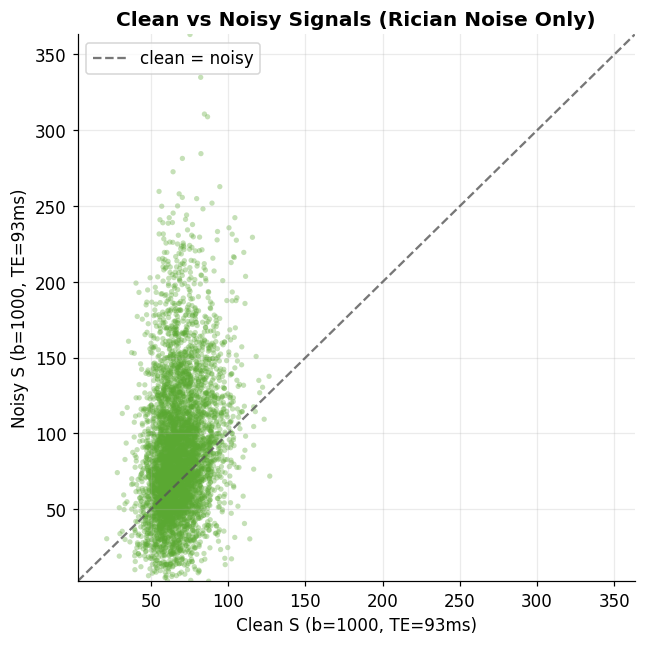

In [6]:
# Plot clean vs noisy signal for a non-trivial acquisition channel
# Avoid channel 0 because b=0, TE=0 gives clean signal ≈ 1000 for every voxel.

fig, ax = plt.subplots(figsize=(6, 6))

n_plot = min(5000, N_TRAIN)
indices = np.random.choice(N_TRAIN, size=n_plot, replace=False)

# Choose a channel with meaningful decay.
# Example: pick the channel closest to b=1000 and TE=93.
channel = np.where((b_grid == 1000) & (te_grid == 93))[0][0]

x = S_clean_tr[indices, channel]
y = X_train[indices, channel]

ax.scatter(
    x, y,
    s=12,
    alpha=0.35,
    color="#5aa832",
    edgecolor="none"
)

# Use data-driven limits instead of forcing [0, 1000].
lim_min = min(x.min(), y.min())
lim_max = max(x.max(), y.max())

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    "--",
    color="#555555",
    lw=1.5,
    alpha=0.8,
    label="clean = noisy"
)
# Clip both axes to the min/max range of the plotted data
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_xlabel(f"Clean S (b={b_grid[channel]:.0f}, TE={te_grid[channel]:.0f}ms)")
ax.set_ylabel(f"Noisy S (b={b_grid[channel]:.0f}, TE={te_grid[channel]:.0f}ms)")
ax.set_title("Clean vs Noisy Signals (Rician Noise Only)", fontweight="bold")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Baseline — NLLS on the Held-Out Synthetic Cohort

NLLS is evaluated before any neural model is trained.

This section:

- creates one held-out clean cohort
- adds fixed Rician noise levels
- fits the 3-compartment model with `curve_fit`
- reports R² and MAE for `D`, `T2`, and `v`
- plots actual vs predicted parameters at the reference clinical noise level

In [18]:
S_clean_test3.shape

(240, 16)

In [7]:
# ── NLLS baseline: held-out cohort, noise sweep, metrics, and helpers ───────
# This cell defines the common evaluation dataset and the baseline NLLS fitter.
# PIA and PIVA reuse the same held-out cohort and same metric helpers later.

SIGMA_TEST_LEVELS = [0.01, 0.03, 0.05, 0.08]   # high SNR → lower clinical SNR
EVAL_SIGMA_REF   = 0.05                        # reference level for scatter plots
NOISE_COLORS     = {0.01: "#70AD47", 0.03: "#5B9BD5", 0.05: "#FFC000", 0.08: "#C0504D"}

N_TEST_PATIENTS         = 24
TEST_VOXELS_PER_PATIENT = 10

# Generate one held-out cohort. All models are tested on this same cohort.
S_clean_test3, D_test3, T2_test3, v_test3, y_test3, patient_ids_test, patient_meta_test = \
    generate_patient_clean_cohort(
        n_patients=N_TEST_PATIENTS,
        voxels_per_patient=TEST_VOXELS_PER_PATIENT,
        seed=999,
    )

N_TEST = S_clean_test3.shape[0]
S_clean_unit_test3 = S_clean_test3 / SIGNAL_SCALE

print(f"Held-out test cohort: {N_TEST_PATIENTS} patients × {TEST_VOXELS_PER_PATIENT} voxels = {N_TEST} voxels")


def add_rician_noise(S_clean_unit, sigma, seed):
    """Add Rician magnitude noise at a fixed unit-scale sigma."""
    rng = np.random.default_rng(seed)
    e_real = rng.normal(0, sigma, S_clean_unit.shape).astype(np.float32)
    e_imag = rng.normal(0, sigma, S_clean_unit.shape).astype(np.float32)
    return SIGNAL_SCALE * np.sqrt((S_clean_unit + e_real) ** 2 + e_imag ** 2).astype(np.float32)


def three_compartment_signal_flat(b_TE, D_ep, D_st, D_lu, T2_ep, T2_st, T2_lu, V_ep, V_st):
    """3-compartment signal model for scipy.curve_fit."""
    b, TE = b_TE
    V_lu = 1.0 - V_ep - V_st
    S_ep = V_ep * np.exp(-b / 1000.0 * D_ep) * np.exp(-TE / T2_ep)
    S_st = V_st * np.exp(-b / 1000.0 * D_st) * np.exp(-TE / T2_st)
    S_lu = V_lu * np.exp(-b / 1000.0 * D_lu) * np.exp(-TE / T2_lu)
    return SIGNAL_SCALE * (S_ep + S_st + S_lu)


def nlls_fit_3comp(signals):
    """Fit 3-compartment parameters voxel-by-voxel with bounded NLLS."""
    D_est  = np.zeros((signals.shape[0], 3), dtype=np.float32)
    T2_est = np.zeros((signals.shape[0], 3), dtype=np.float32)
    v_est  = np.zeros((signals.shape[0], 3), dtype=np.float32)
    valid  = np.ones(signals.shape[0], dtype=bool)

    p0 = [0.55, 1.3, 2.8, 50, 70, 750, 0.3, 0.4]
    lo = [0.3,  0.7, 2.7, 20, 40, 500, 0.0, 0.0]
    hi = [0.7,  1.7, 3.0, 70, 100, 1000, 1.0, 1.0]

    for i in range(signals.shape[0]):
        try:
            coeffs, _ = curve_fit(
                three_compartment_signal_flat,
                b_TE_flat,
                signals[i],
                p0=p0,
                bounds=(lo, hi),
                method="trf",
                maxfev=5000,
            )
        except Exception:
            coeffs = np.array(p0, dtype=float)
            valid[i] = False

        D_est[i]      = coeffs[0:3]
        T2_est[i]     = coeffs[3:6]
        v_est[i, 0:2] = coeffs[6:8]
        v_est[i, 2]   = 1.0 - coeffs[6] - coeffs[7]

    return D_est, T2_est, v_est, valid


def r2_score(true, pred, mask=None):
    """Coefficient of determination across all three compartments jointly."""
    if mask is not None:
        true, pred = true[mask], pred[mask]
    x = true.ravel()
    y = pred.ravel()
    ss_res = np.sum((x - y) ** 2)
    ss_tot = np.sum((x - x.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0.0 else 0.0


def metric_pair(true, pred, mask=None):
    """Return Pearson r and MAE across all compartments jointly."""
    if mask is not None:
        true, pred = true[mask], pred[mask]
    x = true.ravel()
    y = pred.ravel()
    return pearsonr(x, y)[0], float(np.mean(np.abs(x - y)))


def summarize_model_metrics(model_name, D_pred, T2_pred, v_pred, sigma, mask=None):
    """Create one metrics row for a model at one noise level."""
    D_r,  D_mae  = metric_pair(D_test3,  D_pred,  mask)
    T2_r, T2_mae = metric_pair(T2_test3, T2_pred, mask)
    v_r,  v_mae  = metric_pair(v_test3,  v_pred,  mask)

    return {
        "sigma": sigma,
        "model": model_name,
        "D_R2":  r2_score(D_test3,  D_pred,  mask),
        "T2_R2": r2_score(T2_test3, T2_pred, mask),
        "v_R2":  r2_score(v_test3,  v_pred,  mask),
        "D_MAE":  D_mae,
        "T2_MAE": T2_mae,
        "v_MAE":  v_mae,
        "D_r":  D_r,
        "T2_r": T2_r,
        "v_r":  v_r,
    }


def plot_recovery_triplet(model_name, D_pred, T2_pred, v_pred, sigma=EVAL_SIGMA_REF, mask=None):
    """Plot actual vs predicted D, T2, and v for one model at one noise level."""
    if mask is None:
        mask = np.ones(D_test3.shape[0], dtype=bool)

    specs = [
        ("D",  D_test3,  D_pred,  (0.2, 3.3),    "D (×10⁻³ mm²/s)", ".3f"),
        ("T2", T2_test3, T2_pred, (0.0, 1100.0), "T2 (ms)",         ".1f"),
        ("v",  v_test3,  v_pred,  (-0.1, 1.1),   "volume fraction", ".3f"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    color = NOISE_COLORS.get(sigma, "#4472C4")

    for ax, (param_name, true, pred, lims, label, mae_fmt) in zip(axes, specs):
        x = true[mask].ravel()
        y = pred[mask].ravel()
        r2 = r2_score(true, pred, mask)
        _, mae = metric_pair(true, pred, mask)

        ax.scatter(x, y, s=18, alpha=0.45, color=color, edgecolor="none")
        ax.plot(lims, lims, "--", color="#555555", lw=1.3, label="perfect")
        ax.set_xlim(*lims)
        ax.set_ylim(*lims)
        ax.set_xlabel(f"True {param_name}")
        ax.set_ylabel(f"Predicted {param_name}")
        ax.set_title(f"{param_name}: {model_name}", fontweight="bold")
        ax.text(
            0.05, 0.92,
            f"R²={r2:.3f}\nMAE={mae:{mae_fmt}}",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#bbbbbb", alpha=0.9),
        )

    plt.suptitle(f"{model_name}: actual vs predicted parameters at σ={sigma}", fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


# Run NLLS once per test noise level.
plot_results = {}
nlls_rows = []

for seed_offset, sigma in enumerate(SIGMA_TEST_LEVELS):
    X_noisy_test = add_rician_noise(S_clean_unit_test3, sigma, seed=7000 + seed_offset)
    D_nlls, T2_nlls, v_nlls, valid = nlls_fit_3comp(X_noisy_test)

    plot_results[sigma] = {
        "X_noisy": X_noisy_test.astype(np.float32),
        "D_nlls": D_nlls,
        "T2_nlls": T2_nlls,
        "v_nlls": v_nlls,
        "valid": valid,
    }
    nlls_rows.append(summarize_model_metrics("NLLS", D_nlls, T2_nlls, v_nlls, sigma, valid))

nlls_results_df = pd.DataFrame(nlls_rows)
metric_cols = ["sigma", "model", "D_R2", "T2_R2", "v_R2", "D_MAE", "T2_MAE", "v_MAE", "D_r", "T2_r", "v_r"]

print("NLLS baseline metrics")
display(nlls_results_df[metric_cols].round(3))

Held-out test cohort: 24 patients × 10 voxels = 240 voxels
NLLS baseline metrics


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.01,NLLS,0.942,0.834,0.432,0.189,80.147,0.102,0.973,0.935,0.753
1,0.03,NLLS,0.932,0.817,0.456,0.210,88.258,0.106,0.968,0.928,0.752
2,0.05,NLLS,0.923,0.810,0.238,0.225,91.813,0.123,0.963,0.920,0.685
3,0.08,NLLS,0.916,0.812,-0.137,0.240,93.190,0.153,0.961,0.926,0.590


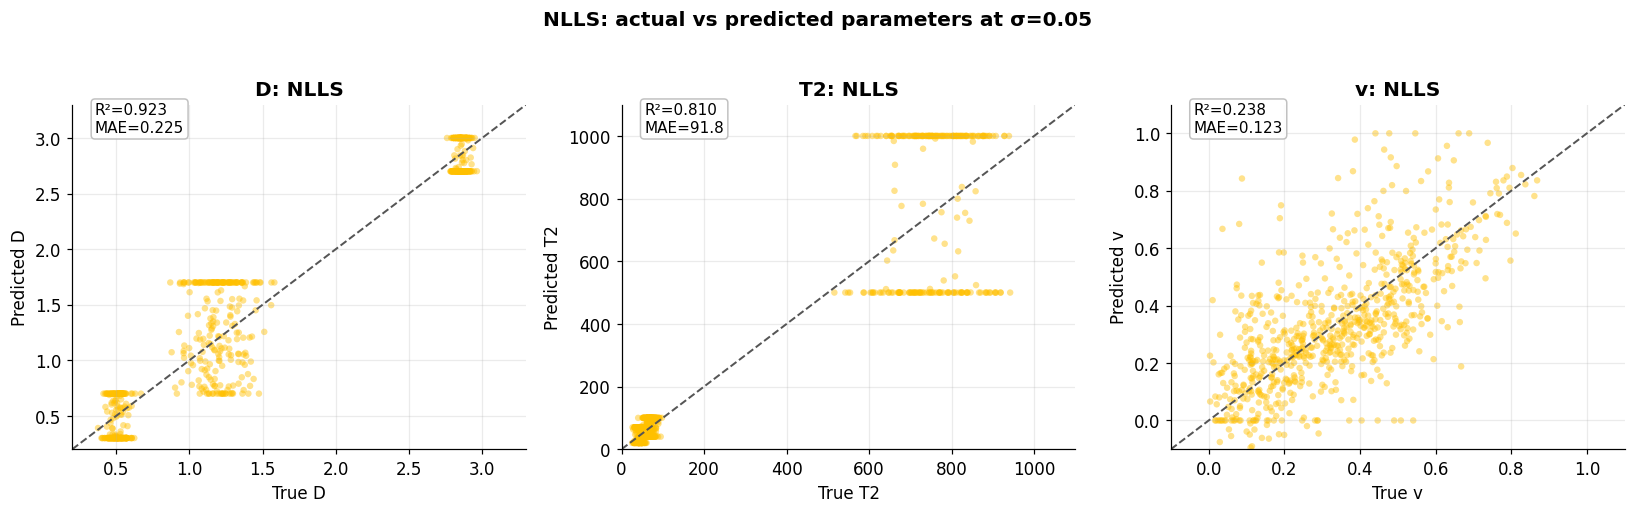

In [8]:
# ── NLLS parameter recovery at the reference clinical noise level ───────────
nlls_ref = plot_results[EVAL_SIGMA_REF]

plot_recovery_triplet(
    "NLLS",
    nlls_ref["D_nlls"],
    nlls_ref["T2_nlls"],
    nlls_ref["v_nlls"],
    sigma=EVAL_SIGMA_REF,
    mask=nlls_ref["valid"],
)

---
## 4. PIA — Deterministic Physics-Informed Autoencoder

PIA replaces voxel-by-voxel optimisation with a neural encoder:

```text
noisy 16-signal vector -> encoder -> D(3), T2(3), v(3)
```

The decoder remains the fixed 3-compartment physics equation:

$$
S(b,TE)=
\sum_{c\in\{ep,st,lu\}}
v_c\exp(-bD_c/1000)\exp(-TE/T2_c)
$$

Training minimises signal reconstruction error. Parameter MAE is monitored
because multiple parameter combinations can reconstruct similar signals.

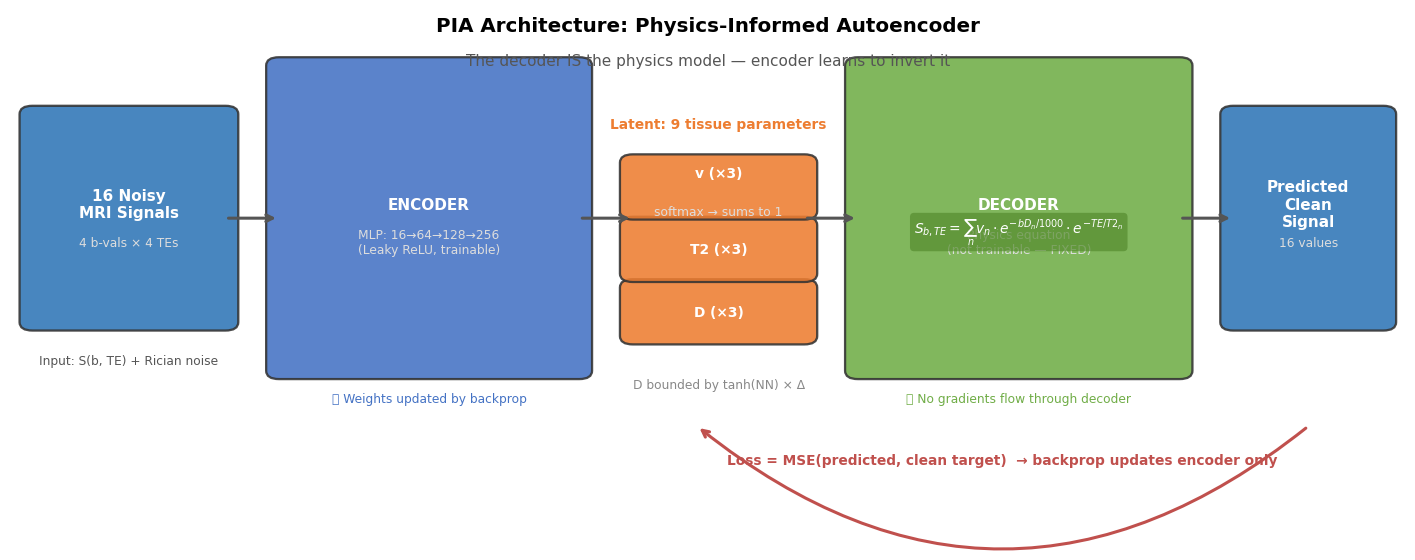

In [7]:
# ── Architecture cartoon ──────────────────────────────────────────────────────
# Draws the PIA encoder→decoder pipeline as a matplotlib diagram.
# Left   = encoder (trainable MLP)
# Middle = latent space (tissue parameters D, T2, v)
# Right  = decoder (fixed physics — not trainable)

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_xlim(0, 13); ax.set_ylim(0, 6); ax.axis('off')

from matplotlib.patches import FancyBboxPatch

def box(ax, x, y, w, h, color, label, sublabel='', fontsize=10):
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor='#333', linewidth=1.5, alpha=0.88)
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2 + (0.2 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize, fontweight='bold', color='white')
    if sublabel:
        ax.text(x + w / 2, y + h / 2 - 0.35, sublabel,
                ha='center', va='center', fontsize=8, color='#ddd')

def arrow(ax, x1, x2, y=3.0, color='#555'):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

# Input signals block
box(ax, 0.2, 1.5, 1.8, 3.0, '#2E75B6', '16 Noisy\nMRI Signals', '4 b-vals × 4 TEs')
ax.text(1.1, 0.9, 'Input: S(b, TE) + Rician noise', ha='center', fontsize=8, color='#555')
arrow(ax, 2.0, 2.5)

# Encoder block (trainable MLP)
box(ax, 2.5, 0.8, 2.8, 4.4, '#4472C4', 'ENCODER', 'MLP: 16→64→128→256\n(Leaky ReLU, trainable)')
ax.text(3.9, 0.35, '✅ Weights updated by backprop', ha='center', fontsize=8, color='#4472C4')
arrow(ax, 5.3, 5.8)

# Latent / output parameters
box(ax, 5.8, 1.3, 1.6, 0.7, '#ED7D31', 'D (×3)', '', fontsize=9)
box(ax, 5.8, 2.2, 1.6, 0.7, '#ED7D31', 'T2 (×3)', '', fontsize=9)
box(ax, 5.8, 3.1, 1.6, 0.7, '#ED7D31', 'v (×3)', 'softmax → sums to 1', fontsize=9)
ax.text(6.6, 4.3, 'Latent: 9 tissue parameters', ha='center', fontsize=9,
        color='#ED7D31', fontweight='bold')
ax.text(6.6, 0.55, 'D bounded by tanh(NN) × Δ', ha='center', fontsize=8, color='#888')
arrow(ax, 7.4, 7.9)

# Decoder block (FIXED physics)
box(ax, 7.9, 0.8, 3.0, 4.4, '#70AD47', 'DECODER', 'Physics equation\n(not trainable — FIXED)', fontsize=10)
ax.text(9.4, 0.35, '❌ No gradients flow through decoder', ha='center', fontsize=8, color='#70AD47')
ax.text(9.4, 2.8,
        r'$S_{b,TE}=\sum_n v_n \cdot e^{-bD_n/1000} \cdot e^{-TE/T2_n}$',
        ha='center', va='center', fontsize=9, color='white',
        bbox=dict(boxstyle='round', facecolor='#558B2F', edgecolor='none', alpha=0.7))
arrow(ax, 10.9, 11.4)

# Output clean signal
box(ax, 11.4, 1.5, 1.4, 3.0, '#2E75B6', 'Predicted\nClean\nSignal', '16 values')

# Loss arrow (goes back to encoder input conceptually)
ax.annotate('', xy=(6.4, 0.0), xytext=(12.1, 0.0),
            arrowprops=dict(arrowstyle='->', color='#C0504D', lw=2,
                            connectionstyle='arc3,rad=-0.4'))
ax.text(9.25, -0.55,
        'Loss = MSE(predicted, clean target)  → backprop updates encoder only',
        ha='center', fontsize=9, color='#C0504D', fontweight='bold')

ax.text(6.5, 5.7, 'PIA Architecture: Physics-Informed Autoencoder',
        ha='center', fontsize=13, fontweight='bold')
ax.text(6.5, 5.2, 'The decoder IS the physics model — encoder learns to invert it',
        ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.show()


In [14]:

# ── Build and train Physics-Informed PIA ─────────────────────────
# This follows the physics-informed forward model closely:
#   encode(x) -> D(3), T2(3), v(3)
#   decode(D,T2,v) -> 16 reconstructed signals
#   loss = MSE(reconstructed signal, clean signal)

pia_device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

if pia_device.type == "cuda":
    torch.set_float32_matmul_precision("high")

BATCH_SIZE = 2048 if pia_device.type == "cuda" else 512
NUM_WORKERS = 2 if pia_device.type == "cuda" else 0
print(f"Using device: {pia_device} | batch size: {BATCH_SIZE}")

pia_train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(S_clean_tr),
    torch.from_numpy(y_train),        # monitoring only
)
pia_train_loader = DataLoader(
    pia_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(pia_device.type == "cuda"),
)




class PIA(nn.Module):
    def __init__(self, number_of_signals=16, hidden_dims=None, predictor_depth=2):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512, 512]

        self.number_of_signals = number_of_signals
        self.number_of_compartments = 3
        self.softmax = nn.Softmax(dim=1)

        # Store physiological constants as model buffers.
        self.register_buffer("D_mean", torch.tensor(D_MEAN_3, dtype=torch.float32))
        self.register_buffer("T2_mean", torch.tensor(T2_MEAN_3, dtype=torch.float32))
        self.register_buffer("D_delta", torch.tensor(D_DELTA_3, dtype=torch.float32))
        self.register_buffer("T2_delta", torch.tensor(T2_DELTA_3, dtype=torch.float32))

        # Shared encoder: 16 MRI signals → deep shared feature representation.
        modules = []
        in_channels = number_of_signals

        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Linear(in_channels, h_dim),
                    nn.LeakyReLU()
                )
            )
            in_channels = h_dim

        self.encoder = nn.Sequential(*modules)

        # Helper function to create each predictor head.
        # Each head has predictor_depth hidden layers, then outputs 3 values.
        def make_predictor(out_dim):
            layers = []

            for _ in range(predictor_depth):
                layers.append(
                    nn.Sequential(
                        nn.Linear(hidden_dims[-1], hidden_dims[-1]),
                        nn.LeakyReLU()
                    )
                )

            layers.append(nn.Linear(hidden_dims[-1], out_dim))
            return nn.Sequential(*layers)

        # Three separate PIA-style heads.
        self.D_predictor = make_predictor(self.number_of_compartments)
        self.T2_predictor = make_predictor(self.number_of_compartments)
        self.v_predictor = make_predictor(self.number_of_compartments)

    def encode(self, x):
        # Pass noisy MRI signal through shared encoder.
        h = self.encoder(x)

        # Predict raw D values, squash with tanh, and map into physiological range.
        D_raw = self.D_predictor(h)
        D = self.D_mean + self.D_delta * torch.tanh(D_raw)

        # Predict raw T2 values, squash with tanh, and map into physiological range.
        T2_raw = self.T2_predictor(h)
        T2 = self.T2_mean + self.T2_delta * torch.tanh(T2_raw)

        # Predict raw volume logits and convert them into fractions summing to 1.
        v_raw = self.v_predictor(h)
        v = self.softmax(v_raw)

        return D, T2, v

    def decode(self, D, T2, v):
        signal = torch.zeros((D.shape[0], self.number_of_signals), device=D.device)

        D, T2, v = D.T, T2.T, v.T

        ctr = 0
        for b in B_VALS:
            for TE in TE_VALS:
                S_ep = v[0] * torch.exp(-b / 1000.0 * D[0]) * torch.exp(-TE / T2[0])
                S_st = v[1] * torch.exp(-b / 1000.0 * D[1]) * torch.exp(-TE / T2[1])
                S_lu = v[2] * torch.exp(-b / 1000.0 * D[2]) * torch.exp(-TE / T2[2])

                signal[:, ctr] = S_ep + S_st + S_lu
                ctr += 1

        return SIGNAL_SCALE * signal

    def forward(self, x):
        # Encode signal into physical tissue parameters.
        D, T2, v = self.encode(x)

        # Decode physical tissue parameters back into MRI signal.
        recon = self.decode(D, T2, v)

        return recon, D, T2, v

    def predict(self, X):
        self.eval()
        x = torch.as_tensor(X, dtype=torch.float32, device=next(self.parameters()).device)
        with torch.no_grad():
            _, D, T2, v = self.forward(x)
        return {
            "D": D.cpu().numpy(),
            "T2": T2.cpu().numpy(),
            "v": v.cpu().numpy(),
        }

# Choose GPU if available, otherwise use CPU.
pia_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pia_encoder = PIA(number_of_signals=N_SIGNALS, predictor_depth=3).to(pia_device)
pia_optimizer = torch.optim.Adam(pia_encoder.parameters(), lr=1e-4)

N_PIA_EPOCHS = 200
pia_history = {"signal_mse": [], "D_mae": [], "T2_mae": [], "v_mae": []}

for epoch in range(1, N_PIA_EPOCHS + 1):
    pia_encoder.train()
    parts = {k: [] for k in pia_history}

    for xb, clean_b, yb in pia_train_loader:
        xb = xb.to(pia_device)
        clean_b = clean_b.to(pia_device)
        yb = yb.to(pia_device)

        pia_optimizer.zero_grad()
        recon, D_hat, T2_hat, v_hat = pia_encoder(xb)
        loss = F.mse_loss(recon, clean_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pia_encoder.parameters(), max_norm=1.0)
        pia_optimizer.step()

        parts["signal_mse"].append(loss.item())
        parts["D_mae"].append(torch.mean(torch.abs(D_hat - yb[:, 0:3])).item())
        parts["T2_mae"].append(torch.mean(torch.abs(T2_hat - yb[:, 3:6])).item())
        parts["v_mae"].append(torch.mean(torch.abs(v_hat - yb[:, 6:9])).item())

    for key in pia_history:
        pia_history[key].append(float(np.mean(parts[key])))

    if epoch == 1 or epoch % 10 == 0 or epoch == N_PIA_EPOCHS:
        print(
            f"Epoch {epoch:03d}/{N_PIA_EPOCHS} | "
            f"signal MSE={pia_history['signal_mse'][-1]:.2f} | "
            f"D MAE={pia_history['D_mae'][-1]:.3f} | "
            f"T2 MAE={pia_history['T2_mae'][-1]:.1f} | "
            f"v MAE={pia_history['v_mae'][-1]:.3f}"
        )

pia_encoder.loss_curve_ = pia_history["signal_mse"]
pia_encoder.n_iter_ = N_PIA_EPOCHS
pia_encoder.loss_ = pia_history["signal_mse"][-1]

print("\n✓ PIA training complete")
print("  encode(x) -> D(3), T2(3), v(3)")
print("  decode(D,T2,v) -> 1000 × sum of ep/st/lu signals")


Using device: cuda | batch size: 2048
Epoch 001/200 | signal MSE=950.94 | D MAE=0.116 | T2 MAE=35.6 | v MAE=0.115
Epoch 010/200 | signal MSE=324.92 | D MAE=0.080 | T2 MAE=34.2 | v MAE=0.080
Epoch 020/200 | signal MSE=305.65 | D MAE=0.085 | T2 MAE=33.7 | v MAE=0.079
Epoch 030/200 | signal MSE=301.39 | D MAE=0.089 | T2 MAE=33.4 | v MAE=0.079
Epoch 040/200 | signal MSE=290.38 | D MAE=0.090 | T2 MAE=33.5 | v MAE=0.079
Epoch 050/200 | signal MSE=280.09 | D MAE=0.089 | T2 MAE=33.5 | v MAE=0.080
Epoch 060/200 | signal MSE=264.70 | D MAE=0.087 | T2 MAE=33.8 | v MAE=0.079
Epoch 070/200 | signal MSE=237.93 | D MAE=0.088 | T2 MAE=34.1 | v MAE=0.079
Epoch 080/200 | signal MSE=213.95 | D MAE=0.087 | T2 MAE=34.2 | v MAE=0.078
Epoch 090/200 | signal MSE=191.19 | D MAE=0.087 | T2 MAE=34.7 | v MAE=0.078
Epoch 100/200 | signal MSE=171.86 | D MAE=0.087 | T2 MAE=34.8 | v MAE=0.078
Epoch 110/200 | signal MSE=155.19 | D MAE=0.087 | T2 MAE=35.0 | v MAE=0.077
Epoch 120/200 | signal MSE=151.45 | D MAE=0.086 | 

In [15]:
def plot_training_diagnostics(history, title):
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))

    plot_specs = [
        ("signal_mse", "Signal reconstruction MSE", "#C0504D", True),
        ("D_mae",      "D MAE monitor",             "#2E75B6", False),
        ("T2_mae",     "T2 MAE monitor",            "#70AD47", False),
        ("v_mae",      "v MAE monitor",             "#ED7D31", False),
    ]

    for ax, (key, panel_title, color, use_log) in zip(axes, plot_specs):
        if key not in history:
            ax.axis("off")
            ax.set_title(f"{panel_title}\nnot available", fontsize=9)
            continue

        values = history[key]
        ax.plot(range(1, len(values) + 1), values, color=color, linewidth=2)
        ax.set_title(panel_title, fontweight="bold", fontsize=10)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(key)
        ax.grid(True, alpha=0.3)

        if use_log:
            ax.set_yscale("log")

    plt.suptitle(title, fontweight="bold", fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()


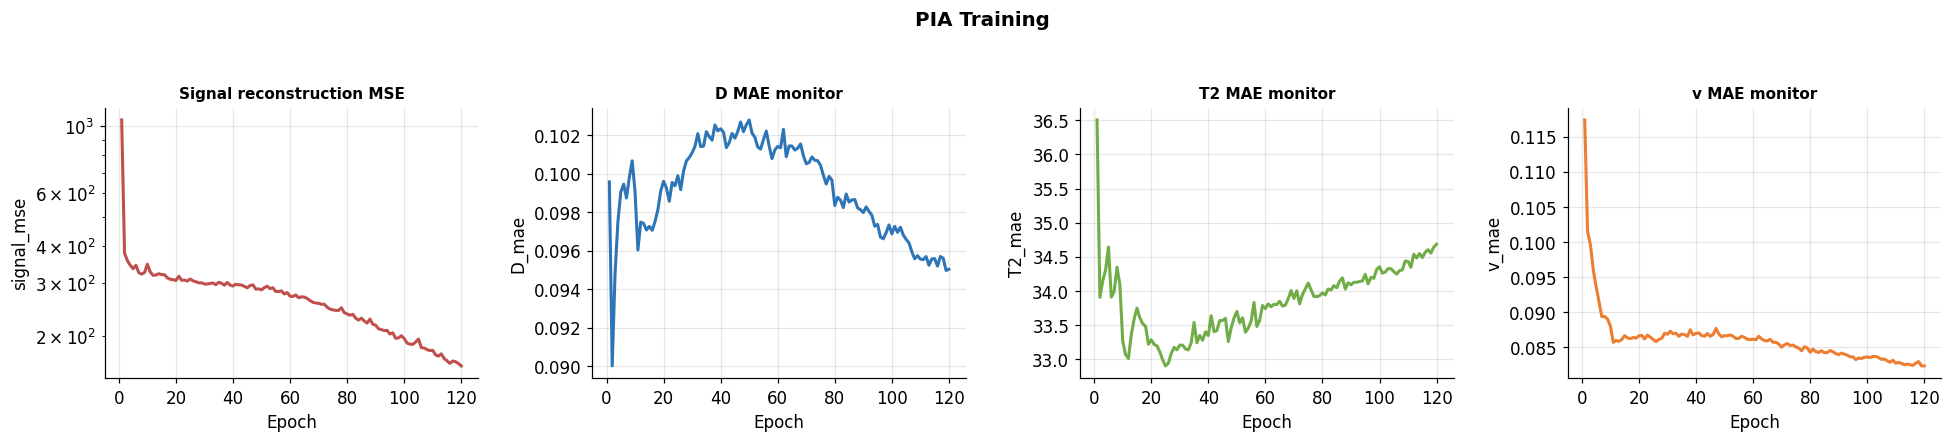

In [10]:
plot_training_diagnostics(pia_history, "PIA Training")


**PIA training note.**  
PIA is trained mainly to reconstruct the clean 16-channel signal. If signal MSE
improves while `D/T2/v` MAE does not improve monotonically, that is an
identifiability warning: different latent parameter combinations can produce
similar MRI signals.

In [16]:
# ── Evaluate trained PIA on the same held-out cohort ───────────────────────
pia_rows = []

for sigma in SIGMA_TEST_LEVELS:
    X_noisy_test = plot_results[sigma]["X_noisy"].astype(np.float32)
    pia_pred = pia_encoder.predict(X_noisy_test)

    plot_results[sigma]["D_pia"]  = pia_pred["D"]
    plot_results[sigma]["T2_pia"] = pia_pred["T2"]
    plot_results[sigma]["v_pia"]  = pia_pred["v"]

    pia_rows.append(
        summarize_model_metrics("PIA", pia_pred["D"], pia_pred["T2"], pia_pred["v"], sigma)
    )

pia_results_df = pd.DataFrame(pia_rows)
pia_nlls_results_df = pd.concat([nlls_results_df, pia_results_df], ignore_index=True)

print("PIA metrics")
display(pia_results_df[metric_cols].round(3))

print("PIA vs NLLS")
display(pia_nlls_results_df[metric_cols].sort_values(["sigma", "model"]).round(3))

PIA metrics


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.01,PIA,0.988,0.960,0.813,0.079,34.885,0.062,0.994,0.980,0.904
1,0.03,PIA,0.986,0.961,0.696,0.083,34.830,0.078,0.994,0.981,0.835
2,0.05,PIA,0.983,0.955,0.580,0.091,37.867,0.091,0.993,0.980,0.767
3,0.08,PIA,0.978,0.959,0.480,0.103,36.650,0.106,0.991,0.981,0.708


PIA vs NLLS


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r
0,0.01,NLLS,0.942,0.834,0.432,0.189,80.147,0.102,0.973,0.935,0.753
4,0.01,PIA,0.988,0.960,0.813,0.079,34.885,0.062,0.994,0.980,0.904
1,0.03,NLLS,0.932,0.817,0.456,0.210,88.258,0.106,0.968,0.928,0.752
5,0.03,PIA,0.986,0.961,0.696,0.083,34.830,0.078,0.994,0.981,0.835
2,0.05,NLLS,0.923,0.810,0.238,0.225,91.813,0.123,0.963,0.920,0.685
6,0.05,PIA,0.983,0.955,0.580,0.091,37.867,0.091,0.993,0.980,0.767
3,0.08,NLLS,0.916,0.812,-0.137,0.240,93.190,0.153,0.961,0.926,0.590
7,0.08,PIA,0.978,0.959,0.480,0.103,36.650,0.106,0.991,0.981,0.708


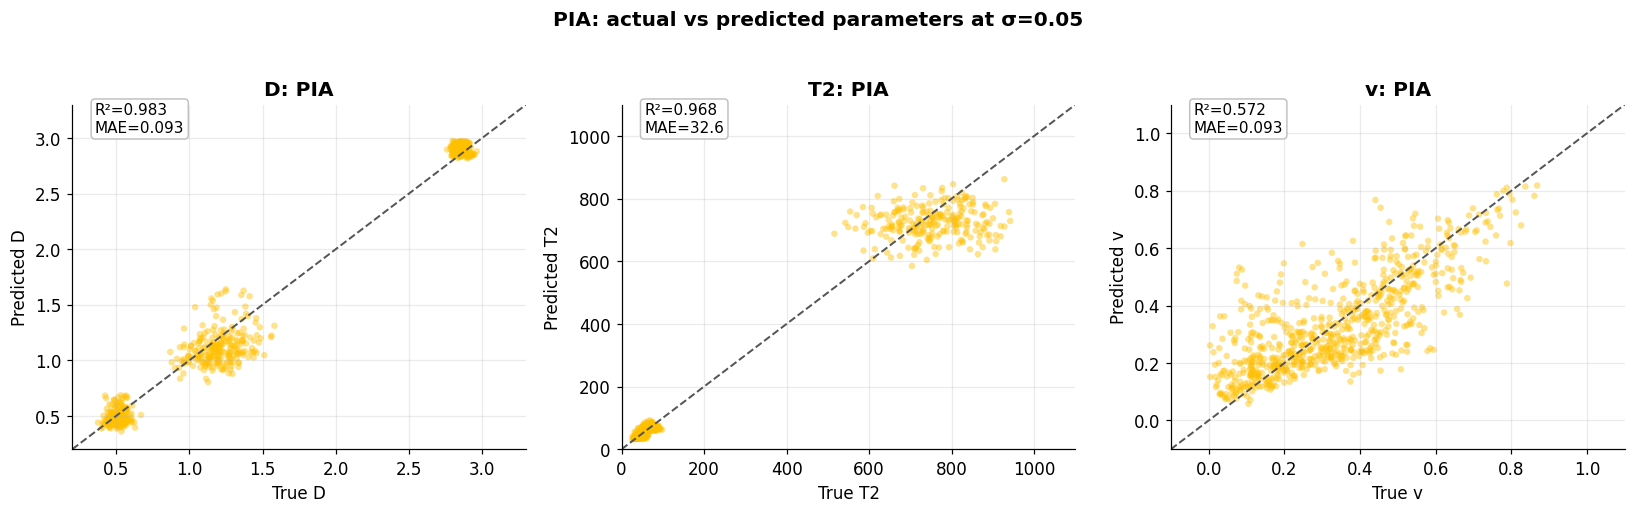

In [12]:
# ── PIA parameter recovery at the reference clinical noise level ────────────
pia_ref = plot_results[EVAL_SIGMA_REF]

plot_recovery_triplet(
    "PIA",
    pia_ref["D_pia"],
    pia_ref["T2_pia"],
    pia_ref["v_pia"],
    sigma=EVAL_SIGMA_REF,
)

---
## 5. PIVA — Variational Physics-Informed Autoencoder

PIVA keeps the same fixed physics decoder as PIA, but makes the latent code
probabilistic:

```text
x -> encoder -> μ, logvar -> sampled z -> D, T2, v -> physics decoder
```

This gives two advantages:

- it can regularise latent parameter recovery
- it can expose posterior uncertainty through Monte Carlo samples

![image.png](attachment:image.png)

In [ ]:
# ── Physics-Informed Variational Autoencoder (PIVA) — Architecture and Variants ──
#
# PIVA extends PIA by replacing the deterministic encoder with a variational one:
#   x → encoder → (μ, log σ²)  [approximate posterior parameters]
#       → z = μ + σ·ε,  ε ~ N(0, I)  [reparameterisation trick]
#       → params_from_z(z) → (D, T2, v)
#       → physics_decoder → Ŝ
#
# Training objective (ELBO):
#   L = MSE(Ŝ, S_clean) + β · KL[ q(z|x) ‖ p(z) ]
#   where KL = -½ Σ (1 + log σ² - μ² - σ²)
#
# Three variants trained here:
#   PIVA-Tight : D = D_mean + D_delta·tanh(z)  [original empirical bounds]
#   PIVA-Wide  : same form, but D_delta × 2    [widened physiological window]
#   PIVA-Free  : D = Softplus(z), T2 = Softplus(z)·10  [no upper bound]


class PIVA(nn.Module):
    """
    Physics-Informed Variational Autoencoder.

    Parameters
    ----------
    n_signals      : int   — length of input MRI signal vector (default 16)
    latent_dim     : int   — VAE latent space dimension (default 9 = 3×D + 3×T2 + 3×v)
    hidden_dims    : list  — encoder layer widths (default matches PIA: [64,128,256,512,512])
    predictor_depth: int   — number of hidden layers in each of the mu/logvar heads
    D_delta        : (3,)  — half-width for tanh constraint on D (None → D_DELTA_3)
    T2_delta       : (3,)  — half-width for tanh constraint on T2 (None → T2_DELTA_3)
    constrained    : bool  — if False, use Softplus instead of tanh (PIVA-Free)
    """
    def __init__(self, n_signals=16, latent_dim=9,
                 hidden_dims=None, predictor_depth=3,
                 D_delta=None, T2_delta=None, constrained=True):
        super().__init__()
        self.constrained = constrained

        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512, 512]   # matches PIA encoder depth

        # ── Encoder: 16 → 64 → 128 → 256 → 512 → 512 ────────────────────────
        modules = []
        in_channels = n_signals
        for h_dim in hidden_dims:
            modules.append(nn.Sequential(
                nn.Linear(in_channels, h_dim),
                nn.LeakyReLU()
            ))
            in_channels = h_dim
        self.encoder = nn.Sequential(*modules)

        # ── Variational heads: predictor-style 512 → 512 → 512 → 9 ──────────
        # Each head has predictor_depth hidden layers before the output projection,
        # matching the depth of PIA's D/T2/v predictor heads.
        def make_head(out_dim):
            layers = []
            for _ in range(predictor_depth):
                layers.append(nn.Sequential(
                    nn.Linear(hidden_dims[-1], hidden_dims[-1]),
                    nn.LeakyReLU()
                ))
            layers.append(nn.Linear(hidden_dims[-1], out_dim))
            return nn.Sequential(*layers)

        self.fc_mu     = make_head(latent_dim)   # posterior mean
        self.fc_logvar = make_head(latent_dim)   # posterior log-variance

        # ── Physiological priors (constrained variants only) ──────────────────
        D_dlt  = D_delta  if D_delta  is not None else D_DELTA_3
        T2_dlt = T2_delta if T2_delta is not None else T2_DELTA_3
        self.register_buffer("D_mean",   torch.tensor(D_MEAN_3,  dtype=torch.float32))
        self.register_buffer("T2_mean",  torch.tensor(T2_MEAN_3, dtype=torch.float32))
        self.register_buffer("D_delta",  torch.tensor(D_dlt,     dtype=torch.float32))
        self.register_buffer("T2_delta", torch.tensor(T2_dlt,    dtype=torch.float32))

    def encode(self, x):
        """
        Map input signals to posterior parameters (μ, log σ²).
        log σ² is clamped to [−8, 4] to prevent numerical collapse.
        """
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(-8.0, 4.0)
        return mu, logvar

    def reparameterize(self, mu, logvar, sample=True):
        """
        Reparameterisation trick: z = μ + σ·ε,  ε ~ N(0, I).
        At test time with sample=False, returns the posterior mean μ.
        """
        if not sample:
            return mu
        eps = torch.randn_like(mu)
        return mu + eps * torch.exp(0.5 * logvar)

    def params_from_z(self, z):
        D_raw, T2_raw, v_raw = z[:, 0:3], z[:, 3:6], z[:, 6:9]

        if self.constrained:
            D  = self.D_mean  + self.D_delta  * torch.tanh(D_raw)
            T2 = self.T2_mean + self.T2_delta * torch.tanh(T2_raw)
            D  = torch.clamp(D,  min=0.01, max=10.0)
            T2 = torch.clamp(T2, min=1.0,  max=2000.0)
        else:
            D  = F.softplus(D_raw)
            T2 = F.softplus(T2_raw) * 10.0
            D  = torch.clamp(D,  min=0.01, max=10.0)
            T2 = torch.clamp(T2, min=1.0,  max=2000.0)

        v = F.softmax(v_raw, dim=1)
        return D, T2, v

    def decode(self, D, T2, v):
        """Physics decoder: delegates to the shared PIA decoder."""
        return pia_encoder.decode(D, T2, v)

    def forward(self, x, sample=True):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar, sample=sample)
        D, T2, v   = self.params_from_z(z)
        recon      = self.decode(D, T2, v)
        return recon, D, T2, v, mu, logvar


def kl_divergence(mu, logvar):
    """
    KL divergence from N(μ, σ²) to standard normal N(0, I).
    KL = -½ Σ (1 + log σ² - μ² - σ²)
    """
    return -0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()


def train_piva(model, loader, n_epochs=200, lr=5e-4, beta=0.1, label="PIVA"):
    """
    Train a PIVA model using the ELBO objective.

    Parameters
    ----------
    model    : PIVA instance
    loader   : DataLoader yielding (X_noisy, S_clean, y_params)
    n_epochs : int   — training epochs
    lr       : float — Adam learning rate
    beta     : float — KL weight in L = signal_MSE + beta × KL
    label    : str   — label for progress printing

    Returns
    -------
    history : dict — training curves keyed by metric name
    """
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = {k: [] for k in ["loss", "signal_mse", "kl", "D_mae", "T2_mae", "v_mae"]}

    for epoch in range(1, n_epochs + 1):
        model.train()
        parts = {k: [] for k in history}

        for xb, clean_b, yb in loader:
            xb, clean_b, yb = xb.to(pia_device), clean_b.to(pia_device), yb.to(pia_device)

            opt.zero_grad()
            recon, D, T2, v, mu, lv = model(xb, sample=True)

            sig_mse = F.mse_loss(recon, clean_b)
            kl      = kl_divergence(mu, lv)
            loss    = sig_mse + beta * kl

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            parts["loss"].append(loss.item())
            parts["signal_mse"].append(sig_mse.item())
            parts["kl"].append(kl.item())
            parts["D_mae"].append(torch.mean(torch.abs(D - yb[:, 0:3])).item())
            parts["T2_mae"].append(torch.mean(torch.abs(T2 - yb[:, 3:6])).item())
            parts["v_mae"].append(torch.mean(torch.abs(v - yb[:, 6:9])).item())

        for k in history:
            history[k].append(float(np.mean(parts[k])))

        if epoch == 1 or epoch % 20 == 0 or epoch == n_epochs:
            print(f"{label} | Epoch {epoch:03d}/{n_epochs} | "
                  f"loss={history['loss'][-1]:.2f} | "
                  f"signal_MSE={history['signal_mse'][-1]:.2f} | "
                  f"KL={history['kl'][-1]:.3f} | "
                  f"D_MAE={history['D_mae'][-1]:.3f} | "
                  f"T2_MAE={history['T2_mae'][-1]:.1f} | "
                  f"v_MAE={history['v_mae'][-1]:.3f}")

    return history


# ── Instantiate and train three PIVA variants ─────────────────────────────────
# PIVA-Tight: D_delta / T2_delta match original empirical ranges exactly
piva_tight = PIVA(n_signals=N_SIGNALS, latent_dim=9,
                  D_delta=D_DELTA_3, T2_delta=T2_DELTA_3,
                  constrained=True).to(pia_device)

# PIVA-Wide: deltas doubled — physiological window widened by 2×
D_DELTA_WIDE  = D_DELTA_3  * 2.0   # [0.4, 1.0, 0.3]
T2_DELTA_WIDE = T2_DELTA_3 * 2.0   # [50, 60, 500]
piva_wide  = PIVA(n_signals=N_SIGNALS, latent_dim=9,
                  D_delta=D_DELTA_WIDE, T2_delta=T2_DELTA_WIDE,
                  constrained=True).to(pia_device)

# PIVA-Free: no tanh constraint — parameters decoded via Softplus
piva_free  = PIVA(n_signals=N_SIGNALS, latent_dim=9,
                  constrained=False).to(pia_device)

print("Training PIVA-Tight ...")
hist_tight = train_piva(piva_tight, pia_train_loader, n_epochs=200, beta=0.1, label="PIVA-Tight")
print("\nTraining PIVA-Wide  ...")
hist_wide  = train_piva(piva_wide,  pia_train_loader, n_epochs=200, beta=0.1, label="PIVA-Wide ")
print("\nTraining PIVA-Free  ...")
hist_free  = train_piva(piva_free,  pia_train_loader, n_epochs=200, beta=0.1, label="PIVA-Free ")

print("\n✓ All three PIVA variants trained")
for label, hist in [("PIVA-Tight", hist_tight), ("PIVA-Wide", hist_wide), ("PIVA-Free", hist_free)]:
    print(f"  {label}: final signal_MSE = {hist['signal_mse'][-1]:.2f}, "
          f"KL = {hist['kl'][-1]:.3f}, v_MAE = {hist['v_mae'][-1]:.4f}")

Training PIVA-Tight ...
PIVA-Tight | Epoch 001/200 | loss=1684.48 | signal_MSE=1681.82 | KL=26.525 | D_MAE=0.092 | T2_MAE=38.9 | v_MAE=0.117
PIVA-Tight | Epoch 020/200 | loss=316.27 | signal_MSE=313.31 | KL=29.601 | D_MAE=0.086 | T2_MAE=29.8 | v_MAE=0.082
PIVA-Tight | Epoch 040/200 | loss=290.89 | signal_MSE=287.92 | KL=29.627 | D_MAE=0.090 | T2_MAE=30.4 | v_MAE=0.084
PIVA-Tight | Epoch 060/200 | loss=256.08 | signal_MSE=253.13 | KL=29.491 | D_MAE=0.087 | T2_MAE=30.2 | v_MAE=0.083
PIVA-Tight | Epoch 080/200 | loss=196.85 | signal_MSE=193.91 | KL=29.368 | D_MAE=0.084 | T2_MAE=30.3 | v_MAE=0.080
PIVA-Tight | Epoch 100/200 | loss=150.40 | signal_MSE=147.45 | KL=29.453 | D_MAE=0.082 | T2_MAE=30.5 | v_MAE=0.077
PIVA-Tight | Epoch 120/200 | loss=122.03 | signal_MSE=119.07 | KL=29.526 | D_MAE=0.082 | T2_MAE=31.0 | v_MAE=0.076
PIVA-Tight | Epoch 140/200 | loss=107.44 | signal_MSE=104.49 | KL=29.433 | D_MAE=0.083 | T2_MAE=31.7 | v_MAE=0.075
PIVA-Tight | Epoch 160/200 | loss=91.72 | signal_MSE=8

In [20]:
hist_free  = train_piva(piva_free,  pia_train_loader, n_epochs=200, beta=0.1, label="PIVA-Free ")

print("\n✓ All three PIVA variants trained")
for label, hist in [("PIVA-Tight", hist_tight), ("PIVA-Wide", hist_wide), ("PIVA-Free", hist_free)]:
    print(f"  {label}: final signal_MSE = {hist['signal_mse'][-1]:.2f}, "
          f"KL = {hist['kl'][-1]:.3f}, v_MAE = {hist['v_mae'][-1]:.4f}")

PIVA-Free  | Epoch 001/200 | loss=408.80 | signal_MSE=375.68 | KL=331.119 | D_MAE=1.286 | T2_MAE=295.8 | v_MAE=0.290
PIVA-Free  | Epoch 020/200 | loss=286.76 | signal_MSE=252.32 | KL=344.419 | D_MAE=1.266 | T2_MAE=297.1 | v_MAE=0.289
PIVA-Free  | Epoch 040/200 | loss=266.36 | signal_MSE=231.68 | KL=346.809 | D_MAE=1.253 | T2_MAE=296.8 | v_MAE=0.286
PIVA-Free  | Epoch 060/200 | loss=255.57 | signal_MSE=220.84 | KL=347.394 | D_MAE=1.234 | T2_MAE=296.4 | v_MAE=0.282
PIVA-Free  | Epoch 080/200 | loss=245.16 | signal_MSE=210.34 | KL=348.142 | D_MAE=1.223 | T2_MAE=295.9 | v_MAE=0.278
PIVA-Free  | Epoch 100/200 | loss=244.50 | signal_MSE=209.63 | KL=348.722 | D_MAE=1.209 | T2_MAE=295.4 | v_MAE=0.272
PIVA-Free  | Epoch 120/200 | loss=223.31 | signal_MSE=188.14 | KL=351.633 | D_MAE=1.201 | T2_MAE=295.0 | v_MAE=0.265
PIVA-Free  | Epoch 140/200 | loss=219.80 | signal_MSE=184.73 | KL=350.666 | D_MAE=1.197 | T2_MAE=294.5 | v_MAE=0.255
PIVA-Free  | Epoch 160/200 | loss=211.48 | signal_MSE=176.17 | K

In [22]:
# ── Evaluate PIVA variants on the same held-out cohort ─────────────────────
def mc_predict_piva(model, X, n_mc=25):
    """Monte Carlo posterior mean and standard deviation for one PIVA model."""
    x = torch.as_tensor(X, dtype=torch.float32, device=pia_device)
    D_samples, T2_samples, v_samples = [], [], []

    model.eval()
    with torch.no_grad():
        for _ in range(n_mc):
            _, D, T2, v, _, _ = model(x, sample=True)
            D_samples.append(D.cpu().numpy())
            T2_samples.append(T2.cpu().numpy())
            v_samples.append(v.cpu().numpy())

    D_s  = np.stack(D_samples)
    T2_s = np.stack(T2_samples)
    v_s  = np.stack(v_samples)

    return {
        "D":    D_s.mean(axis=0),  "T2":    T2_s.mean(axis=0),  "v":    v_s.mean(axis=0),
        "D_sd": D_s.std(axis=0),   "T2_sd": T2_s.std(axis=0),   "v_sd": v_s.std(axis=0),
    }


piva_eval_tight = {}
piva_eval_wide  = {}
piva_eval_free  = {}
piva_rows = []

for sigma in SIGMA_TEST_LEVELS:
    X_noisy = plot_results[sigma]["X_noisy"].astype(np.float32)

    pred_tight = mc_predict_piva(piva_tight, X_noisy, n_mc=25)
    pred_wide  = mc_predict_piva(piva_wide,  X_noisy, n_mc=25)
    pred_free  = mc_predict_piva(piva_free,  X_noisy, n_mc=25)

    piva_eval_tight[sigma] = pred_tight
    piva_eval_wide[sigma]  = pred_wide
    piva_eval_free[sigma]  = pred_free

    for model_name, pred in [
        ("PIVA-Tight", pred_tight),
        ("PIVA-Wide",  pred_wide),
        ("PIVA-Free",  pred_free),
    ]:
        row = summarize_model_metrics(model_name, pred["D"], pred["T2"], pred["v"], sigma)
        row["D_sd"]  = pred["D_sd"].mean()
        row["T2_sd"] = pred["T2_sd"].mean()
        row["v_sd"]  = pred["v_sd"].mean()
        piva_rows.append(row)

piva_results_df = pd.DataFrame(piva_rows)
all_results_df = pd.concat([nlls_results_df, pia_results_df, piva_results_df], ignore_index=True)

piva_cols = metric_cols + ["D_sd", "T2_sd", "v_sd"]

#print("PIVA metrics")
#display(piva_results_df[piva_cols].round(3))

print("All models")
display(all_results_df[piva_cols].sort_values(["sigma", "model"]).round(3))

All models


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE,D_r,T2_r,v_r,D_sd,T2_sd,v_sd
0,0.01,NLLS,0.942,0.834,0.432,0.189,80.147,0.102,0.973,0.935,0.753,NaN,NaN,NaN
4,0.01,PIA,0.988,0.960,0.813,0.079,34.885,0.062,0.994,0.980,0.904,NaN,NaN,NaN
10,0.01,PIVA-Free,-1.356,-0.658,-1.626,1.216,301.464,0.242,-0.289,-0.395,-0.145,0.011,0.488,0.004
8,0.01,PIVA-Tight,0.988,0.966,0.783,0.077,33.615,0.066,0.994,0.987,0.890,0.009,4.356,0.004
9,0.01,PIVA-Wide,0.972,0.905,0.627,0.116,55.804,0.091,0.987,0.955,0.816,0.012,3.426,0.005
1,0.03,NLLS,0.932,0.817,0.456,0.210,88.258,0.106,0.968,0.928,0.752,NaN,NaN,NaN
5,0.03,PIA,0.986,0.961,0.696,0.083,34.830,0.078,0.994,0.981,0.835,NaN,NaN,NaN
13,0.03,PIVA-Free,-1.351,-0.654,-1.633,1.214,300.687,0.241,-0.291,-0.393,-0.142,0.011,0.512,0.004
11,0.03,PIVA-Tight,0.988,0.966,0.688,0.076,34.062,0.080,0.994,0.987,0.831,0.009,4.499,0.004
12,0.03,PIVA-Wide,0.974,0.912,0.573,0.111,54.241,0.098,0.988,0.958,0.773,0.012,3.543,0.005


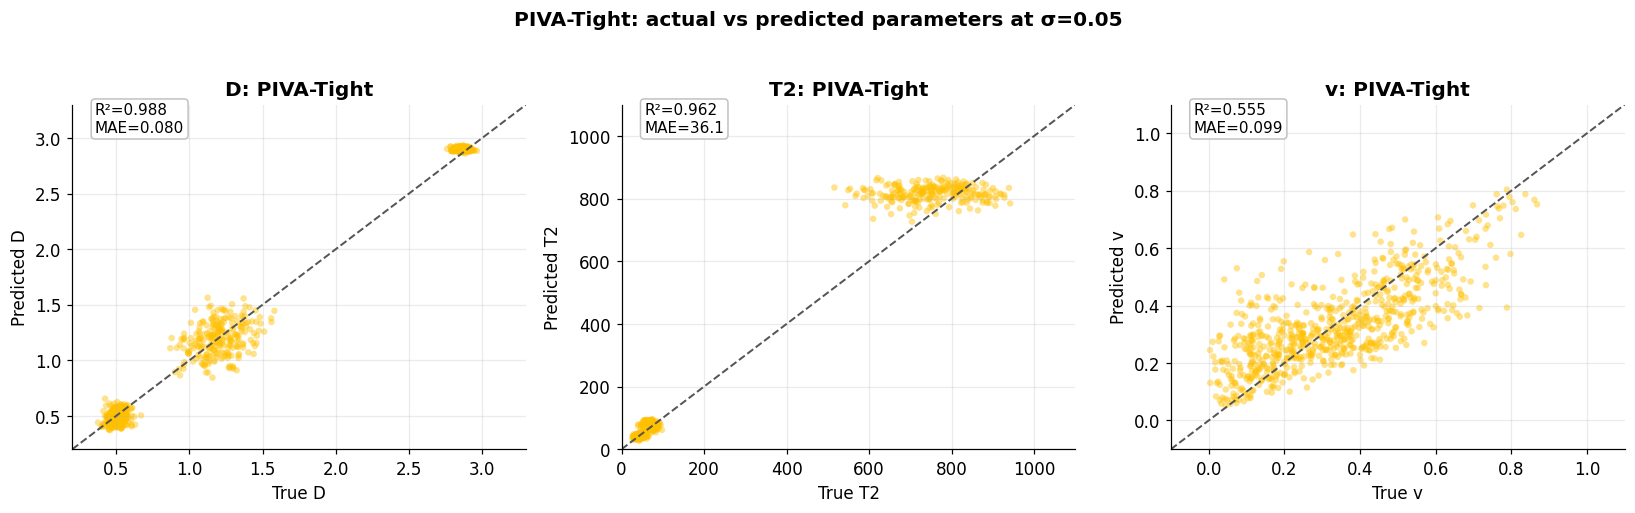

In [23]:
# ── PIVA-Tight parameter recovery at the reference clinical noise level ─────
# PIVA-Tight is used as the main PIVA readout; all variants are compared below.
piva_ref = piva_eval_tight[EVAL_SIGMA_REF]

plot_recovery_triplet(
    "PIVA-Tight",
    piva_ref["D"],
    piva_ref["T2"],
    piva_ref["v"],
    sigma=EVAL_SIGMA_REF,
)

Mean voxel uncertainty score (CV) at σ=0.05: 0.0071
Range: [0.0037, 0.0110]


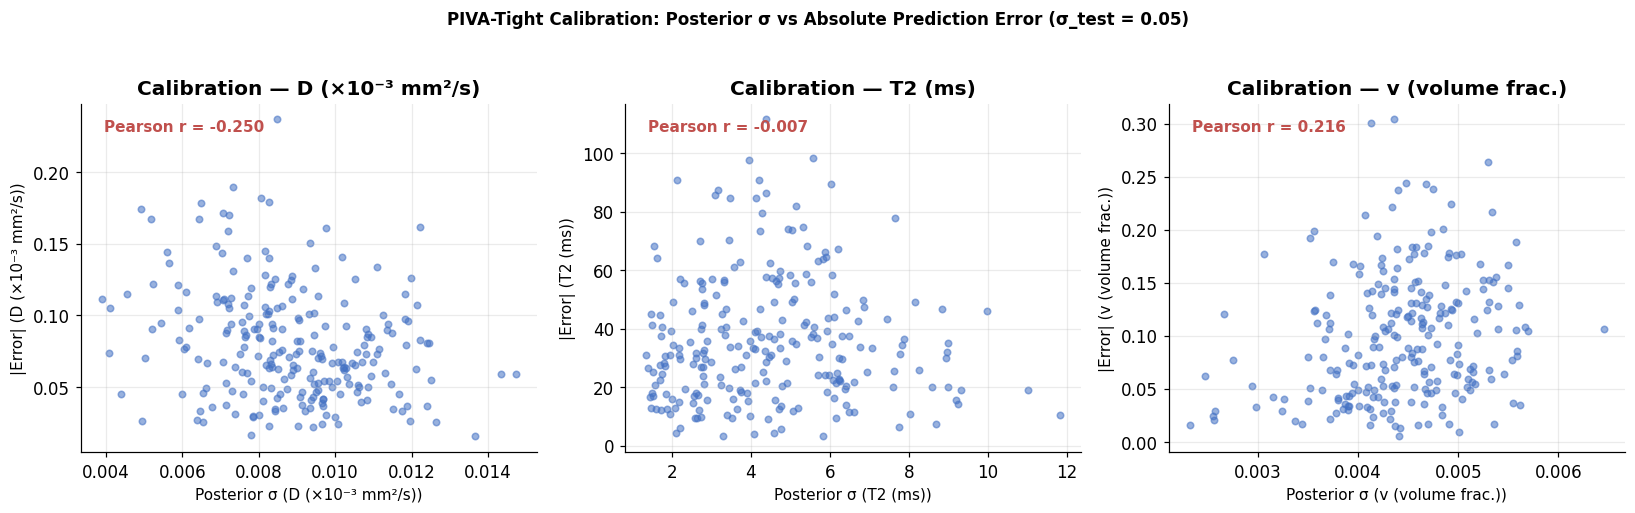


── 95% Credible Interval Coverage ───────────────────────────────
  (PIVA-Tight, σ_test = 0.05)
  D (×10⁻³ mm²/s)     : empirical 95% CI coverage = 0.156  (target 0.950)
  T2 (ms)             : empirical 95% CI coverage = 0.085  (target 0.950)
  v (volume frac.)    : empirical 95% CI coverage = 0.053  (target 0.950)

── Coverage at all noise levels (PIVA-Tight, D parameter) ───────
  σ=0.01 (SNR≈100:1): D coverage = 0.197
  σ=0.03 (SNR≈33:1): D coverage = 0.189
  σ=0.05 (SNR≈20:1): D coverage = 0.156
  σ=0.08 (SNR≈12:1): D coverage = 0.154


In [24]:
# ── Confidence metrics derived from PIVA posterior ───────────────────────────────
#
# Three structured uncertainty diagnostics:
#   1. Coefficient of Variation (CV) — normalised per-voxel uncertainty score
#   2. Calibration analysis        — does posterior σ predict actual error?
#   3. 95% Credible Interval Coverage — empirical vs nominal coverage rate
#
# Analysis is shown for PIVA-Tight at σ=0.05 (clinical SNR) as the reference case.
# The same functions apply to all variants.

sigma_ref  = 0.05                           # clinical SNR reference case
pred_ref   = piva_eval_tight[sigma_ref]     # PIVA-Tight posterior at σ=0.05

# ── 1. Coefficient of Variation ───────────────────────────────────────────────
# CV_i = σ_i / |μ_i|  — dimensionless measure of uncertainty per parameter
eps     = 1e-6   # prevents division by zero
D_cv    = pred_ref["D_sd"]  / (np.abs(pred_ref["D"])  + eps)   # (N, 3)
T2_cv   = pred_ref["T2_sd"] / (np.abs(pred_ref["T2"]) + eps)   # (N, 3)
v_cv    = pred_ref["v_sd"]                                       # (N, 3) already in (0,1)

# Scalar uncertainty score per voxel: mean CV across all 9 latent dimensions
uncertainty_score = np.concatenate([D_cv, T2_cv, v_cv], axis=1).mean(axis=1)  # (N,)
print(f"Mean voxel uncertainty score (CV) at σ=0.05: {uncertainty_score.mean():.4f}")
print(f"Range: [{uncertainty_score.min():.4f}, {uncertainty_score.max():.4f}]")

# ── 2. Calibration analysis ───────────────────────────────────────────────────
# A well-calibrated posterior: voxels with high σ_D should have high |D_pred − D_true|.
# Pearson r between uncertainty and error quantifies calibration quality.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
param_specs = [
    ("D (×10⁻³ mm²/s)", D_test3, pred_ref["D"], pred_ref["D_sd"]),
    ("T2 (ms)",          T2_test3, pred_ref["T2"], pred_ref["T2_sd"]),
    ("v (volume frac.)", v_test3,  pred_ref["v"],  pred_ref["v_sd"]),
]
for ax, (pname, true_p, pred_p, sd_p) in zip(axes, param_specs):
    # Per-voxel mean absolute error and mean posterior σ
    abs_err     = np.abs(true_p - pred_p).mean(axis=1)   # (N,) — average over compartments
    mean_sd     = sd_p.mean(axis=1)                       # (N,)
    cal_r, _    = pearsonr(mean_sd, abs_err)

    ax.scatter(mean_sd, abs_err, s=18, alpha=0.55, color="#4472C4")
    ax.set_xlabel(f"Posterior σ ({pname})", fontsize=10)
    ax.set_ylabel(f"|Error| ({pname})", fontsize=10)
    ax.set_title(f"Calibration — {pname}", fontweight="bold")
    ax.text(0.05, 0.92, f"Pearson r = {cal_r:.3f}",
            transform=ax.transAxes, fontsize=10, color="#C0504D", fontweight="bold")

plt.suptitle("PIVA-Tight Calibration: Posterior σ vs Absolute Prediction Error (σ_test = 0.05)",
             fontweight="bold", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

# ── 3. 95% Credible Interval Coverage ─────────────────────────────────────────
# Nominal 95% CI: [μ − 1.96σ, μ + 1.96σ]  (Gaussian approximation to posterior)
# Empirical coverage = fraction of test voxels for which true value lies in the CI.
# Ideal: coverage ≈ 0.95. Under-coverage → CI too narrow (overconfident).

print("\n── 95% Credible Interval Coverage ───────────────────────────────")
print(f"  (PIVA-Tight, σ_test = {sigma_ref})")
for pname, true_p, pred_p, sd_p in param_specs:
    lower    = pred_p - 1.96 * sd_p         # lower bound of 95% CI
    upper    = pred_p + 1.96 * sd_p         # upper bound of 95% CI
    coverage = ((true_p >= lower) & (true_p <= upper)).mean()
    print(f"  {pname:20s}: empirical 95% CI coverage = {coverage:.3f}  (target 0.950)")

print("\n── Coverage at all noise levels (PIVA-Tight, D parameter) ───────")
for sigma in SIGMA_TEST_LEVELS:
    pred_s = piva_eval_tight[sigma]
    lower  = pred_s["D"] - 1.96 * pred_s["D_sd"]
    upper  = pred_s["D"] + 1.96 * pred_s["D_sd"]
    cov    = ((D_test3 >= lower) & (D_test3 <= upper)).mean()
    print(f"  σ={sigma:.2f} (SNR≈{1/sigma:.0f}:1): D coverage = {cov:.3f}")


---
## 6. Final Comparison — NLLS vs PIA vs PIVA

The final section compares all methods on the same held-out cohort and the same
reference noise level. Use the table for quantitative comparison and the scatter
plots for parameter-specific failure modes.

Final comparison at σ=0.05


,sigma,model,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE
0,0.05,NLLS,0.923,0.810,0.238,0.225,91.813,0.123
1,0.05,PIA,0.983,0.968,0.572,0.093,32.553,0.093
2,0.05,PIVA-Free,-1.483,-0.658,-2.231,1.345,303.877,0.285
3,0.05,PIVA-Tight,0.952,0.788,0.254,0.173,94.932,0.128
4,0.05,PIVA-Wide,0.819,0.797,0.111,0.342,85.917,0.139


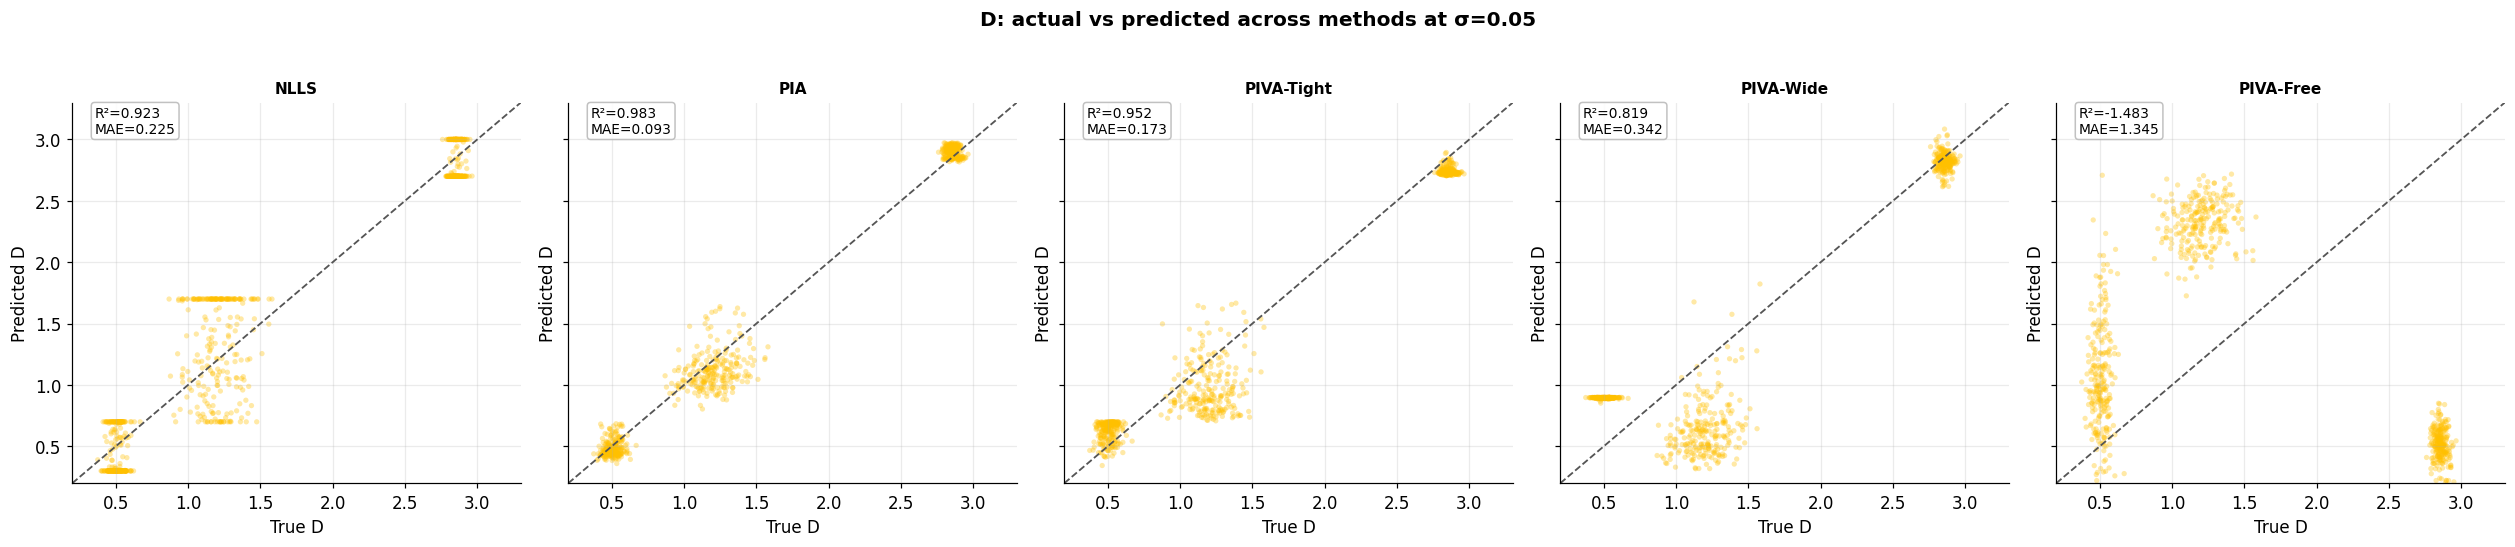

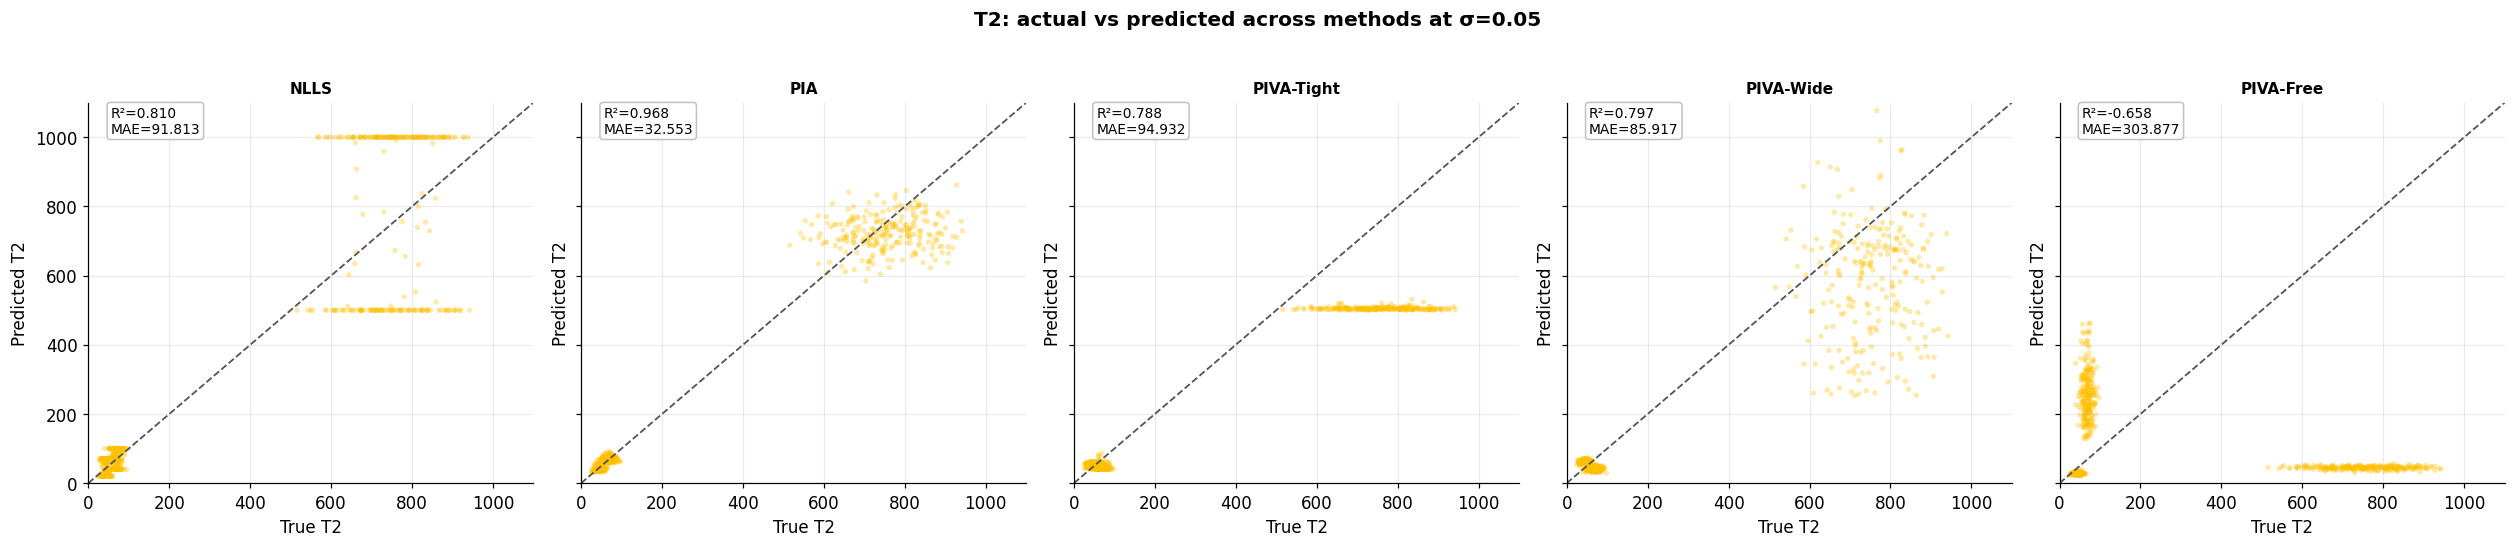

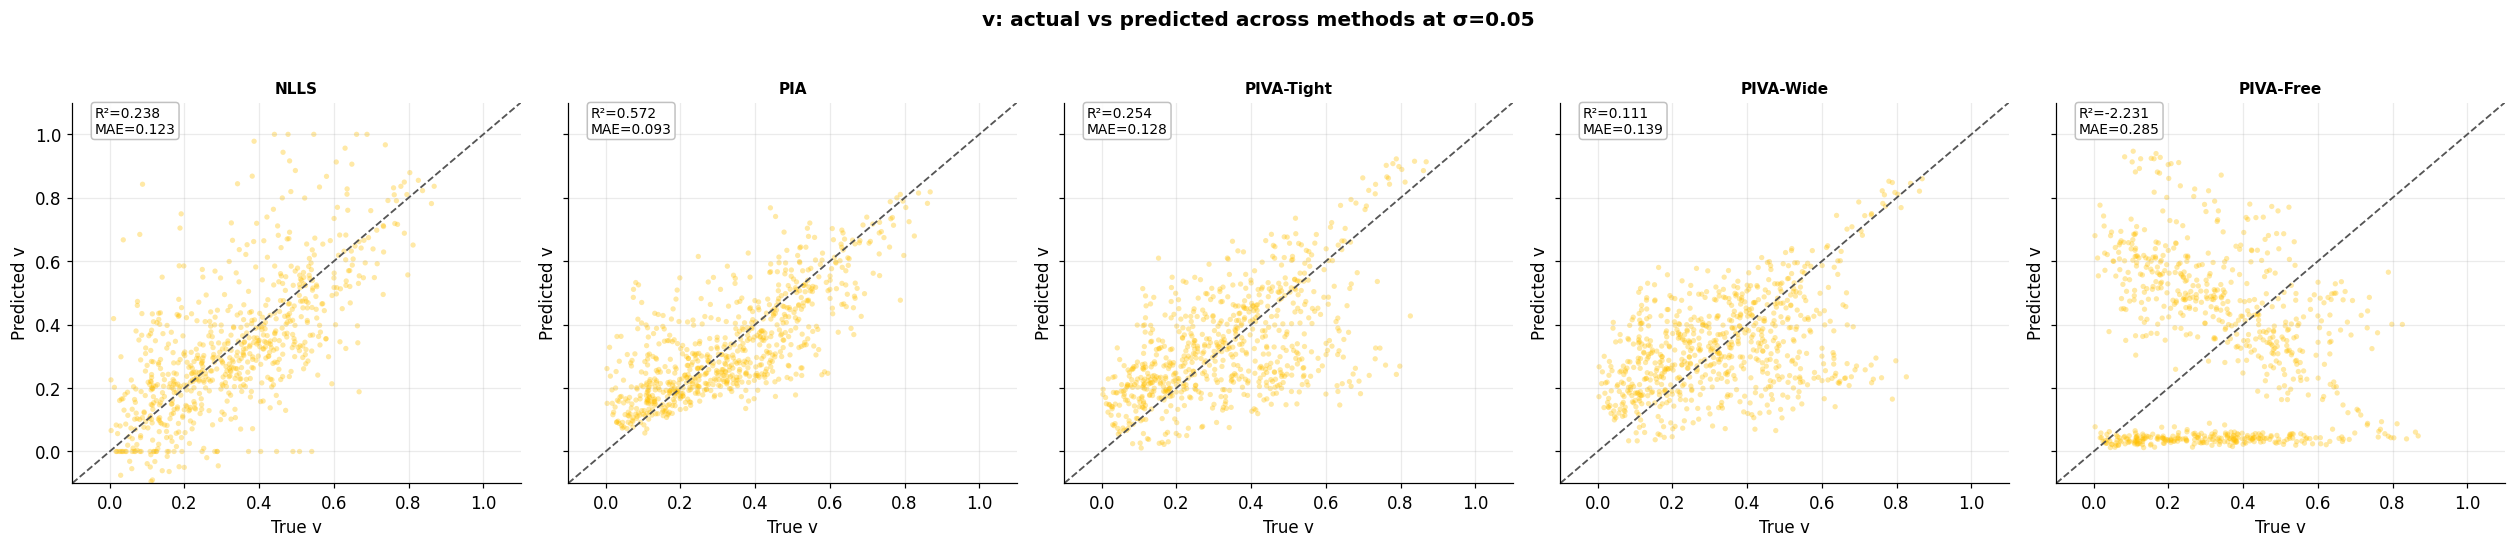

In [17]:
# ── Final compact comparison table and scatter plots ───────────────────────
summary_cols = ["sigma", "model", "D_R2", "T2_R2", "v_R2", "D_MAE", "T2_MAE", "v_MAE"]

print(f"Final comparison at σ={EVAL_SIGMA_REF}")
final_ref_df = (
    all_results_df
    .loc[all_results_df["sigma"].eq(EVAL_SIGMA_REF), summary_cols]
    .sort_values("model")
    .reset_index(drop=True)
)
display(final_ref_df.round(3))


def get_model_prediction(model_name, sigma=EVAL_SIGMA_REF):
    res = plot_results[sigma]
    if model_name == "NLLS":
        return res["D_nlls"], res["T2_nlls"], res["v_nlls"], res["valid"]
    if model_name == "PIA":
        return res["D_pia"], res["T2_pia"], res["v_pia"], None
    if model_name == "PIVA-Tight":
        p = piva_eval_tight[sigma]
        return p["D"], p["T2"], p["v"], None
    if model_name == "PIVA-Wide":
        p = piva_eval_wide[sigma]
        return p["D"], p["T2"], p["v"], None
    if model_name == "PIVA-Free":
        p = piva_eval_free[sigma]
        return p["D"], p["T2"], p["v"], None
    raise ValueError(model_name)


def plot_all_models_for_param(param_name, true_values, pred_index, lims, sigma=EVAL_SIGMA_REF):
    model_names = ["NLLS", "PIA", "PIVA-Tight", "PIVA-Wide", "PIVA-Free"]
    fig, axes = plt.subplots(1, len(model_names), figsize=(23, 4.8), sharex=True, sharey=True)

    for ax, model_name in zip(axes, model_names):
        D_pred, T2_pred, v_pred, mask = get_model_prediction(model_name, sigma)
        pred_values = [D_pred, T2_pred, v_pred][pred_index]

        if mask is None:
            mask = np.ones(true_values.shape[0], dtype=bool)

        x = true_values[mask].ravel()
        y = pred_values[mask].ravel()
        r2 = r2_score(true_values, pred_values, mask)
        _, mae = metric_pair(true_values, pred_values, mask)

        ax.scatter(x, y, s=12, alpha=0.35, color=NOISE_COLORS[sigma], edgecolor="none")
        ax.plot(lims, lims, "--", color="#555555", lw=1.2)
        ax.set_xlim(*lims)
        ax.set_ylim(*lims)
        ax.set_title(model_name, fontweight="bold", fontsize=10)
        ax.set_xlabel(f"True {param_name}")
        ax.set_ylabel(f"Predicted {param_name}")
        ax.text(
            0.05, 0.92,
            f"R²={r2:.3f}\nMAE={mae:.3f}",
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#bbbbbb", alpha=0.9),
        )

    plt.suptitle(f"{param_name}: actual vs predicted across methods at σ={sigma}", fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


plot_all_models_for_param("D",  D_test3,  0, (0.2, 3.3))
plot_all_models_for_param("T2", T2_test3, 1, (0.0, 1100.0))
plot_all_models_for_param("v",  v_test3,  2, (-0.1, 1.1))

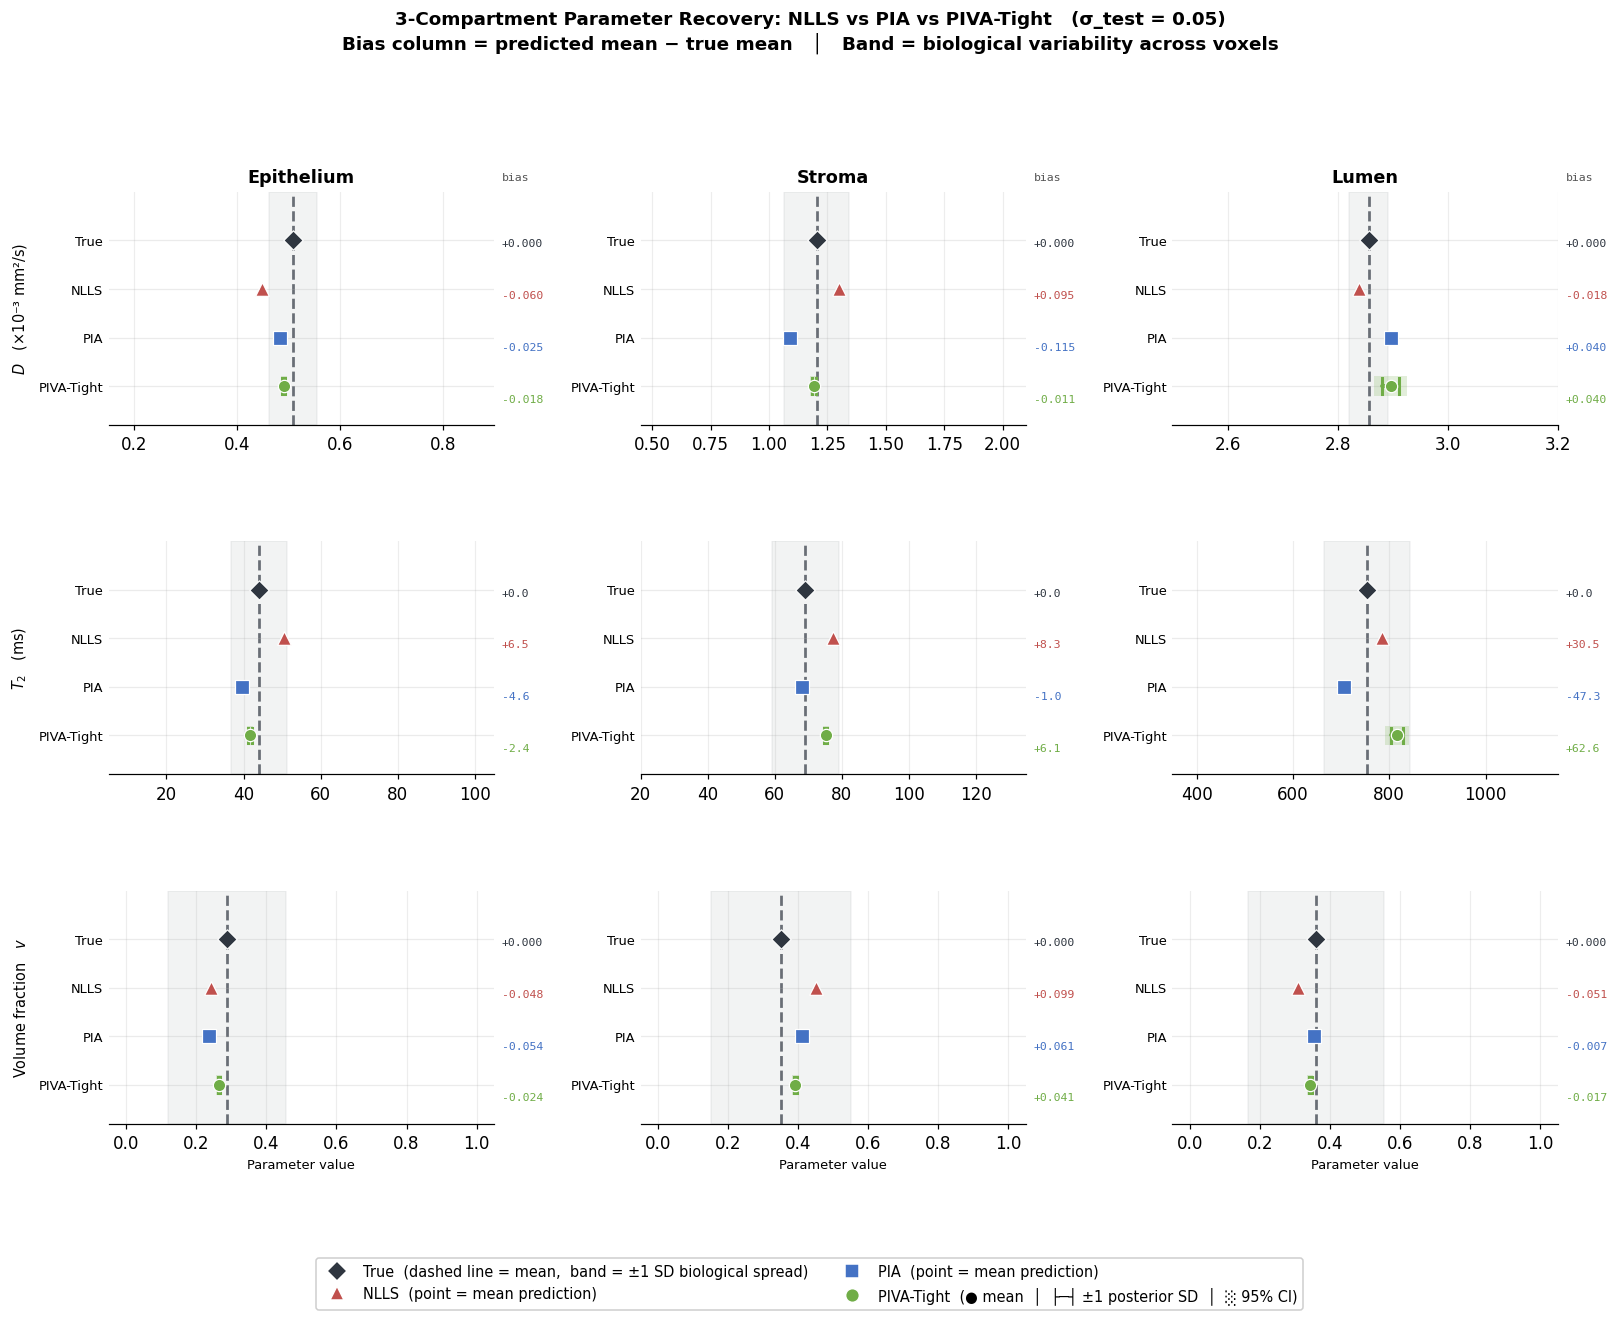

In [26]:
# ── 3×3 Forest Plot: Parameter Recovery Comparison ───────────────────────────
# Rows: D, T2, v    |    Cols: Epithelium, Stroma, Lumen
# Each panel: horizontal number line showing True, NLLS, PIA, PIVA-Tight
#
# Requires (all already in memory from prior cells):
#   D_test3, T2_test3, v_test3, plot_results, piva_eval_tight, EVAL_SIGMA_REF
#
# If running after the β-sweep instead of the original PIVA cell, replace:
#   piva_eval_tight[SIGMA]  →  mc_predict(piva_beta_models[0.1], X_NOISY_EVAL)

import matplotlib.lines as mlines

SIGMA     = EVAL_SIGMA_REF           # 0.05
ref       = plot_results[SIGMA]
nlls_mask = ref["valid"]
piva      = piva_eval_tight[SIGMA]   # swap here for β-sweep model

# ── Layout ────────────────────────────────────────────────────────────────────
PARAMS       = ["D", "T2", "v"]
PARAM_LABELS = {
    "D":  r"$D$   (×10⁻³ mm²/s)",
    "T2": r"$T_2$   (ms)",
    "v":  r"Volume fraction   $v$",
}
COMP_LABELS = ["Epithelium", "Stroma", "Lumen"]

# x-axis limits: slightly wider than physiological bounds to show NLLS outliers
XLIMS = {
    "D":  [(0.15, 0.90), (0.45, 2.10), (2.50, 3.20)],
    "T2": [(5,   105),   (20,  135),   (350, 1150)],
    "v":  [(-0.05, 1.05)] * 3,
}

# y positions for the 4 method rows within each panel
Y_POS   = {"True": 3.5, "NLLS": 2.5, "PIA": 1.5, "PIVA-Tight": 0.5}
COLORS  = {
    "True":       "#2F3640",
    "NLLS":       "#C0504D",
    "PIA":        "#4472C4",
    "PIVA-Tight": "#70AD47",
}
MARKERS = {"True": "D", "NLLS": "^", "PIA": "s", "PIVA-Tight": "o"}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(17, 11))
fig.subplots_adjust(hspace=0.50, wspace=0.38)

for row_i, param in enumerate(PARAMS):
    for col_j in range(3):
        ax = axes[row_i, col_j]
        c  = col_j   # compartment index: 0=ep, 1=st, 2=lu

        # ── Per-compartment arrays ────────────────────────────────────────────
        true_arr = {"D": D_test3, "T2": T2_test3, "v": v_test3}[param][:, c]
        nlls_arr = {"D": ref["D_nlls"], "T2": ref["T2_nlls"],
                    "v": ref["v_nlls"]}[param][nlls_mask, c]
        pia_arr  = {"D": ref["D_pia"],  "T2": ref["T2_pia"],
                    "v": ref["v_pia"]}[param][:, c]
        piva_mu  = piva[param][:, c]
        piva_sd  = piva[f"{param}_sd"][:, c]

        # ── Summary statistics ────────────────────────────────────────────────
        stats = {
            "True":       (true_arr.mean(), true_arr.std(),  None),
            "NLLS":       (nlls_arr.mean(), None,            None),
            "PIA":        (pia_arr.mean(),  None,            None),
            "PIVA-Tight": (piva_mu.mean(),  piva_sd.mean(),  1.96 * piva_sd.mean()),
        }
        true_mean, true_sd, _ = stats["True"]

        xlims = XLIMS[param][c]
        ax.set_xlim(*xlims)
        ax.set_ylim(-0.3, 4.5)

        # ── True reference: dashed vertical line + ±1SD biological band ──────
        ax.axvline(true_mean, color=COLORS["True"], lw=1.8, ls="--",
                   alpha=0.7, zorder=1)
        ax.axvspan(true_mean - true_sd, true_mean + true_sd,
                   color=COLORS["True"], alpha=0.06, zorder=0,
                   label="_nolegend_")

        # ── Method markers ────────────────────────────────────────────────────
        x_range = xlims[1] - xlims[0]

        for method in ["True", "NLLS", "PIA", "PIVA-Tight"]:
            y   = Y_POS[method]
            mu, sd, ci_half = stats[method]
            col = COLORS[method]
            mrk = MARKERS[method]

            if method == "PIVA-Tight":
                # 95% CI shaded rectangle
                ax.barh(y, 2 * ci_half, left=mu - ci_half,
                        height=0.40, color=col, alpha=0.20, zorder=2)
                # ±1 SD whisker line
                ax.plot([mu - sd, mu + sd], [y, y],
                        color=col, lw=2.5, solid_capstyle="round", zorder=3)
                # Whisker caps
                for sign in [-1, +1]:
                    ax.plot([mu + sign * sd] * 2, [y - 0.16, y + 0.16],
                            color=col, lw=2.0, zorder=3)
                ax.scatter([mu], [y], color=col, s=65, zorder=4,
                           marker=mrk, edgecolors="white", linewidths=0.8)
            else:
                ax.scatter([mu], [y], color=col, s=80, zorder=4,
                           marker=mrk, edgecolors="white", linewidths=0.8)

            # Bias label (signed, right-aligned outside plot)
            bias = mu - true_mean
            fmt  = ".3f" if param in ("D", "v") else ".1f"
            bias_str = f"{bias:+{fmt}}"
            ax.text(1.02, (y - 0.0) / 4.5, bias_str,
                    transform=ax.transAxes,
                    fontsize=7.5, va="center", color=col,
                    fontfamily="monospace")

        # Bias column header (top panel only)
        if row_i == 0:
            ax.text(1.02, 1.04, "bias", transform=ax.transAxes,
                    fontsize=7.5, va="bottom", color="#555555",
                    fontfamily="monospace")

        # ── y-axis: method labels ─────────────────────────────────────────────
        ax.set_yticks(list(Y_POS.values()))
        ax.set_yticklabels(list(Y_POS.keys()), fontsize=8.5)
        ax.tick_params(axis="y", length=0)

        # ── Titles, labels, grid ──────────────────────────────────────────────
        if row_i == 0:
            ax.set_title(COMP_LABELS[col_j], fontweight="bold", fontsize=11.5)
        if col_j == 0:
            ax.set_ylabel(PARAM_LABELS[param], fontsize=9.5, labelpad=6)
        if row_i == 2:
            ax.set_xlabel("Parameter value", fontsize=8.5)

        ax.grid(axis="x", alpha=0.22)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mlines.Line2D([0], [0], marker="D", color="w",
                  markerfacecolor=COLORS["True"], markersize=9,
                  label=r"True  (dashed line = mean,  band = ±1 SD biological spread)"),
    mlines.Line2D([0], [0], marker="^", color="w",
                  markerfacecolor=COLORS["NLLS"], markersize=9,
                  label="NLLS  (point = mean prediction)"),
    mlines.Line2D([0], [0], marker="s", color="w",
                  markerfacecolor=COLORS["PIA"], markersize=9,
                  label="PIA  (point = mean prediction)"),
    mlines.Line2D([0], [0], marker="o", color="w",
                  markerfacecolor=COLORS["PIVA-Tight"], markersize=9,
                  label=r"PIVA-Tight  (● mean  │  ├─┤ ±1 posterior SD  │  ░ 95% CI)"),
]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=2,
    fontsize=9.5, frameon=True, framealpha=0.95,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    f"3-Compartment Parameter Recovery: NLLS vs PIA vs PIVA-Tight   "
    f"(σ_test = {SIGMA})\n"
    r"Bias column = predicted mean − true mean   │   "
    r"Band = biological variability across voxels",
    fontweight="bold", fontsize=12, y=1.03,
)

plt.show()

In [ ]:
# variational part-
# claude code-
# create a github repo and add prof as colab
# MAE is the best , pearson, rho
# PIVA doing similar  to PIA but erors similar to sigma
# if the posterior can be generated similar to the prior
# methodology section- using llm- mark in red what is already existing and mark the gap
# Result section wek 6



────────────────────────────────────────────────────────────
Training PIVA-Tight-β0.01
────────────────────────────────────────────────────────────
PIVA-Tight-β0.01 | Epoch 001/200 | β=0.000 | loss=2128.28 | sigMSE=2128.27 | KL=26.502 | D_MAE=0.108 | T2_MAE=40.2 | v_MAE=0.133
PIVA-Tight-β0.01 | Epoch 020/200 | β=0.004 | loss=312.96 | sigMSE=312.84 | KL=32.005 | D_MAE=0.077 | T2_MAE=29.7 | v_MAE=0.082
PIVA-Tight-β0.01 | Epoch 040/200 | β=0.008 | loss=291.42 | sigMSE=291.17 | KL=31.783 | D_MAE=0.083 | T2_MAE=30.8 | v_MAE=0.081
PIVA-Tight-β0.01 | Epoch 060/200 | β=0.010 | loss=221.45 | sigMSE=221.13 | KL=31.366 | D_MAE=0.081 | T2_MAE=31.4 | v_MAE=0.078
PIVA-Tight-β0.01 | Epoch 080/200 | β=0.010 | loss=171.88 | sigMSE=171.56 | KL=31.403 | D_MAE=0.079 | T2_MAE=31.5 | v_MAE=0.075
PIVA-Tight-β0.01 | Epoch 100/200 | β=0.010 | loss=140.32 | sigMSE=140.01 | KL=31.476 | D_MAE=0.078 | T2_MAE=31.9 | v_MAE=0.072
PIVA-Tight-β0.01 | Epoch 120/200 | β=0.010 | loss=105.39 | sigMSE=105.08 | KL=31.418 | 

,D_R2,T2_R2,v_R2,D_MAE,T2_MAE,v_MAE
beta_max,,,,,,
0.01,0.9879,0.9679,0.5679,0.0764,32.7658,0.0975
0.10,0.9874,0.9676,0.5795,0.0789,33.0855,0.0956
0.30,0.9871,0.9071,0.5530,0.0836,57.0448,0.0997
1.00,0.9843,0.8817,0.5709,0.0888,65.5924,0.0987
3.00,0.9386,0.9153,0.1431,0.1788,57.5750,0.1323



── Posterior σ magnitude ───────────────────────────────────────────


,D_mean_sd,T2_mean_sd,v_mean_sd
beta_max,,,
0.01,0.00523,1.76000,0.00456
0.10,0.00844,4.42038,0.00451
0.30,0.01387,8.47458,0.00456
1.00,0.02264,13.15125,0.00591
3.00,0.04412,23.20266,0.00941



── 95% CI Coverage (target 0.950) ──────────────────────────────────


,D_cov95,T2_cov95,v_cov95
beta_max,,,
0.01,0.0861,0.0819,0.0667
0.10,0.1514,0.1042,0.0681
0.30,0.2097,0.1014,0.0472
1.00,0.3069,0.1306,0.0611
3.00,0.3486,0.2194,0.0903



── Calibration Pearson r (σ vs |error|) ─────────────────────────────


,D_cal_r,T2_cal_r,v_cal_r
beta_max,,,
0.01,-0.2759,-0.1055,0.2551
0.10,-0.1214,-0.0402,0.2669
0.30,-0.0562,-0.0449,0.1351
1.00,-0.1736,-0.2791,0.1360
3.00,-0.0736,-0.3281,0.0870


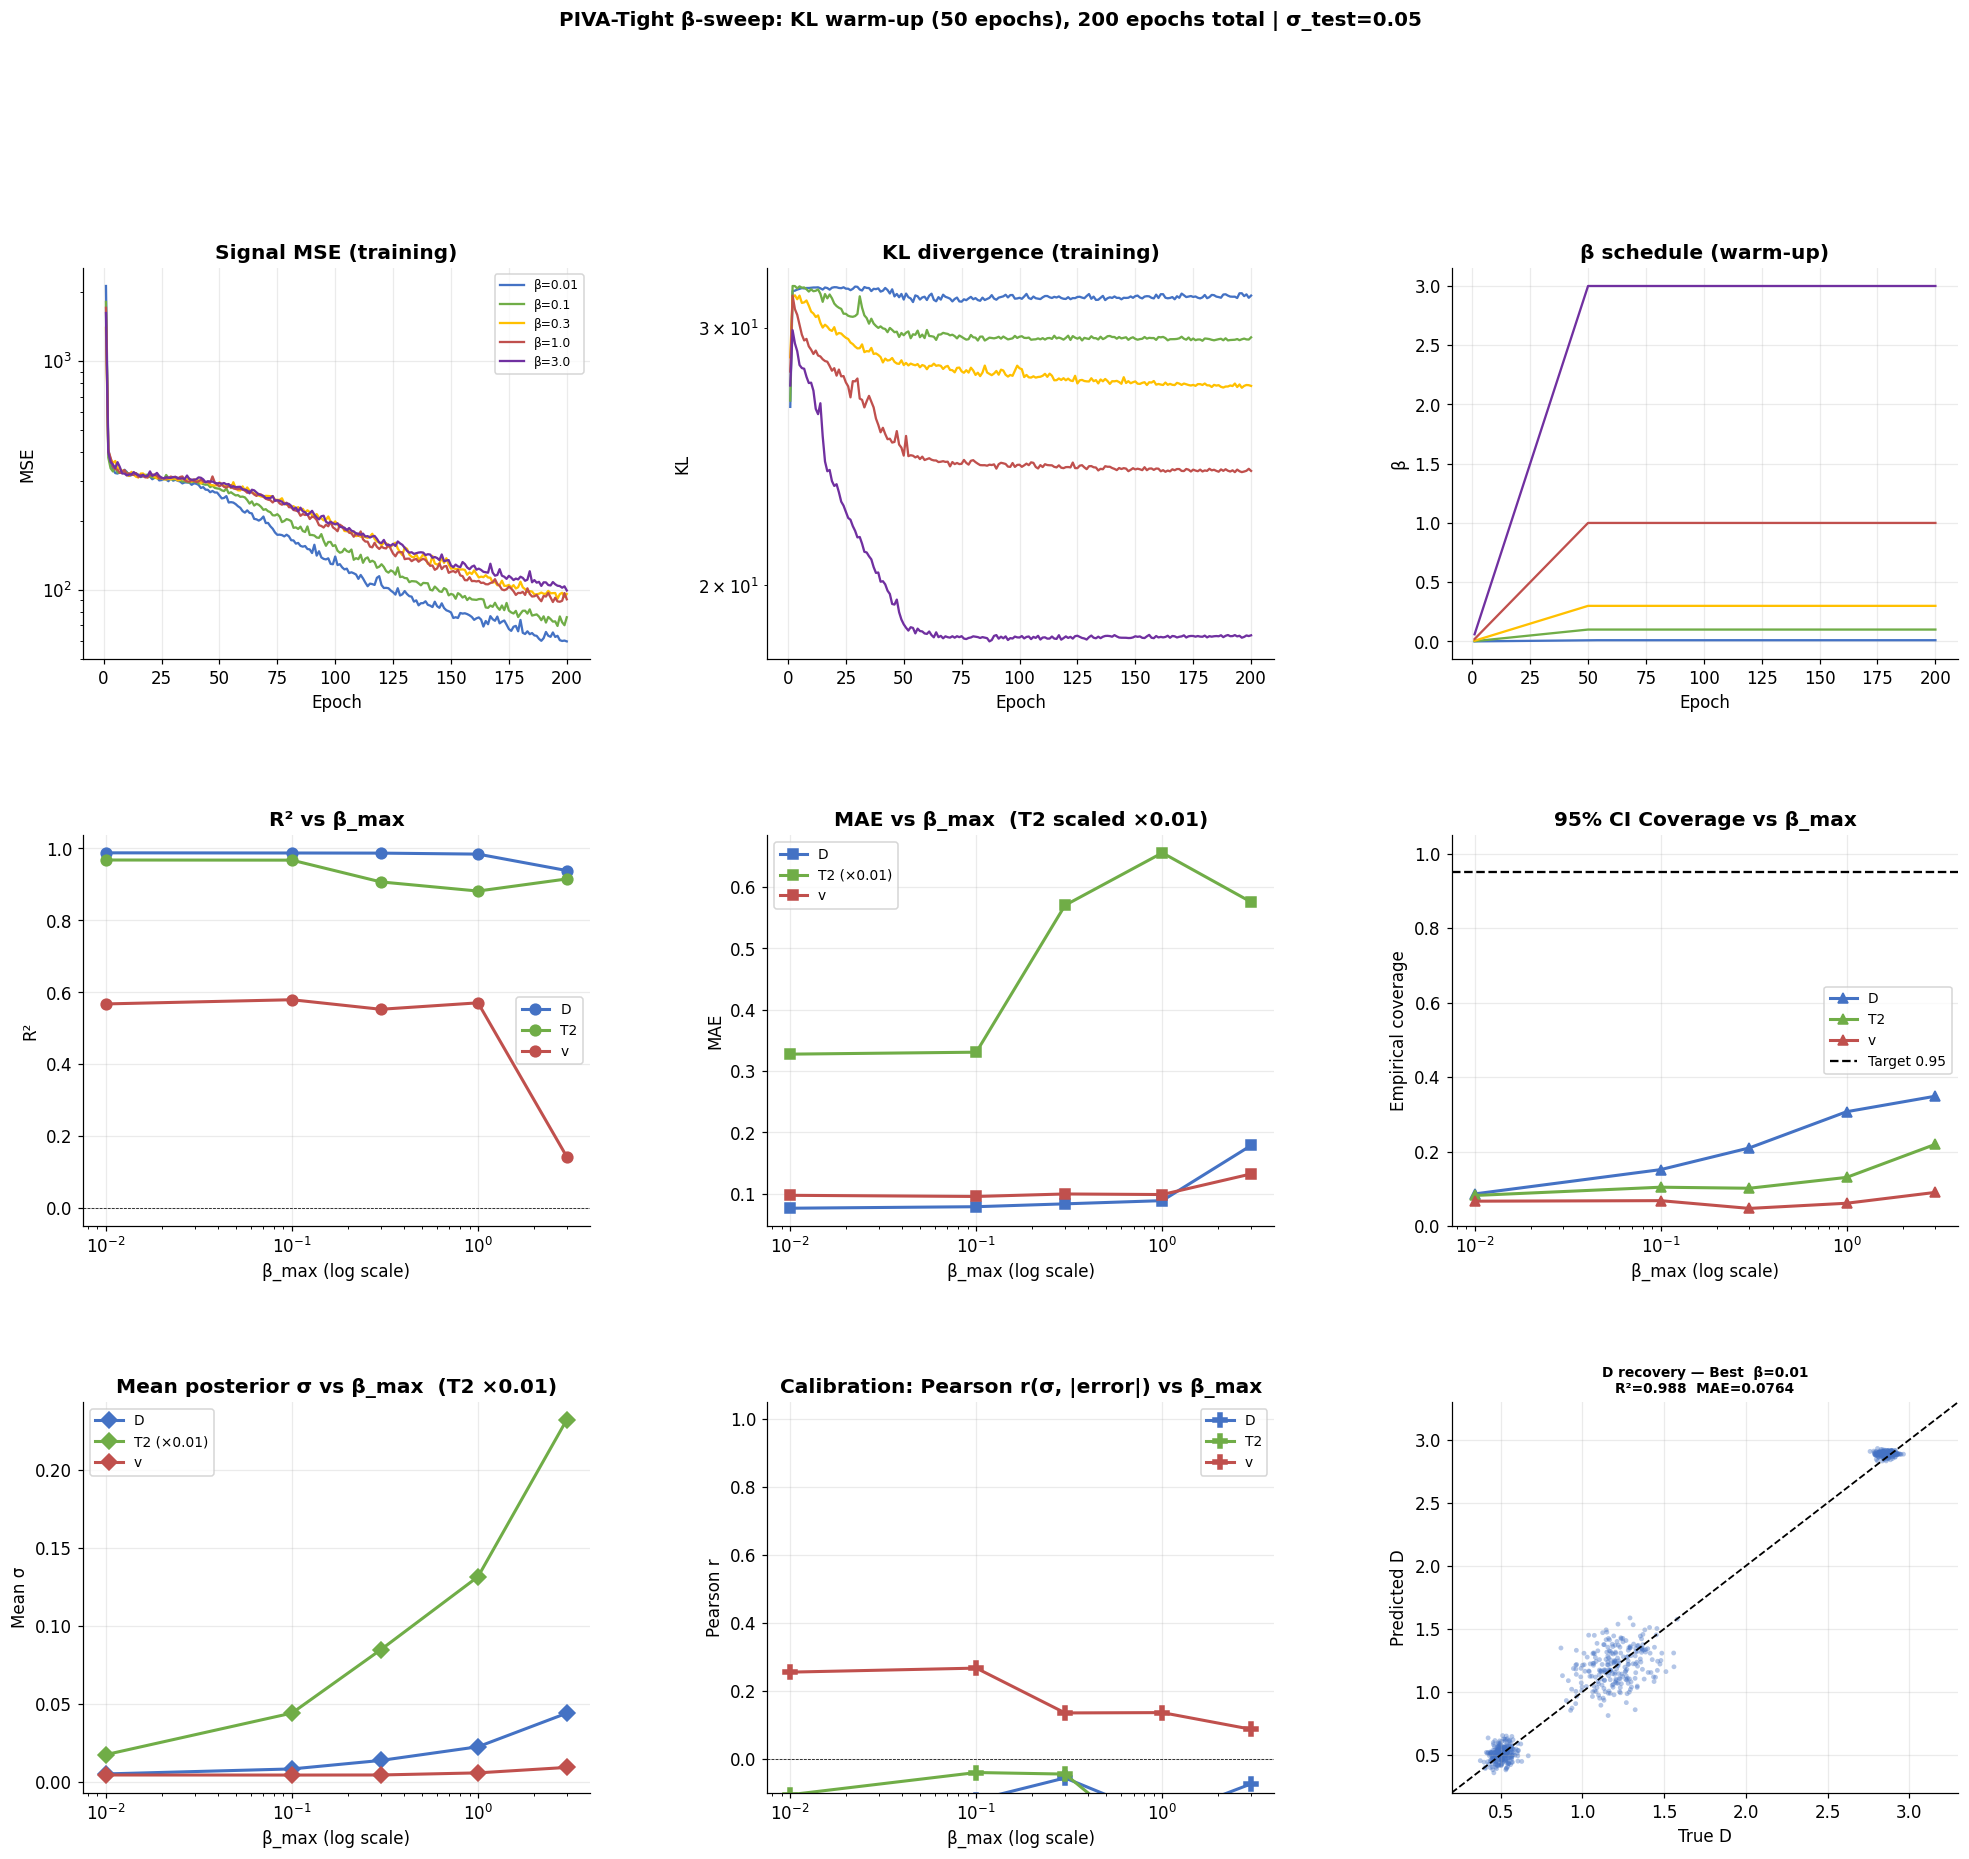


── Recommendation ───────────────────────────────────────────────────
  Best D R²   : β=0.01  →  R²=0.9879
  Best coverage (closest to 0.95): β=3.0  →  D=0.349  T2=0.219  v=0.090


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PIVA β-SWEEP EXPERIMENT — KL warm-up, PIVA-Tight only
#
# Self-contained cell. Assumes prior cells have been run:
#   pia_device, pia_encoder, PIVA class, pia_train_loader,
#   N_SIGNALS, D_DELTA_3, T2_DELTA_3, D_MEAN_3, T2_MEAN_3,
#   D_DELTA_WIDE, T2_DELTA_WIDE, plot_results, D_test3, T2_test3, v_test3,
#   EVAL_SIGMA_REF, SIGNAL_SCALE, pearsonr
#
# Questions answered:
#   1. Does higher β improve 95% CI coverage?
#   2. Does posterior σ grow with β?
#   3. Does R²/MAE degrade badly at high β?
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── 1. Loss and training ──────────────────────────────────────────────────────

def kl_divergence(mu, logvar):
    """KL[ N(μ,σ²) ‖ N(0,I) ] = -½ Σ (1 + log σ² - μ² - σ²)"""
    return -0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()


def train_piva(model, loader, n_epochs=200, lr=5e-4,
               beta_max=1.0, warmup_epochs=50, label="PIVA"):
    """
    ELBO training with linear KL warm-up.
    β linearly ramps from 0 → beta_max over the first warmup_epochs,
    then stays at beta_max.
    """
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = {k: [] for k in
               ["loss", "signal_mse", "kl", "beta", "D_mae", "T2_mae", "v_mae"]}

    for epoch in range(1, n_epochs + 1):
        model.train()
        parts = {k: [] for k in history if k != "beta"}

        beta = beta_max * min(1.0, epoch / warmup_epochs)

        for xb, clean_b, yb in loader:
            xb, clean_b, yb = (xb.to(pia_device),
                                clean_b.to(pia_device),
                                yb.to(pia_device))

            opt.zero_grad()
            recon, D, T2, v, mu, lv = model(xb, sample=True)

            sig_mse = F.mse_loss(recon, clean_b)
            kl      = kl_divergence(mu, lv)
            loss    = sig_mse + beta * kl

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            parts["loss"].append(loss.item())
            parts["signal_mse"].append(sig_mse.item())
            parts["kl"].append(kl.item())
            parts["D_mae"].append(torch.mean(torch.abs(D - yb[:, 0:3])).item())
            parts["T2_mae"].append(torch.mean(torch.abs(T2 - yb[:, 3:6])).item())
            parts["v_mae"].append(torch.mean(torch.abs(v - yb[:, 6:9])).item())

        for k in parts:
            history[k].append(float(np.mean(parts[k])))
        history["beta"].append(float(beta))

        if epoch == 1 or epoch % 20 == 0 or epoch == n_epochs:
            print(
                f"{label} | Epoch {epoch:03d}/{n_epochs} | "
                f"β={beta:.3f} | "
                f"loss={history['loss'][-1]:.2f} | "
                f"sigMSE={history['signal_mse'][-1]:.2f} | "
                f"KL={history['kl'][-1]:.3f} | "
                f"D_MAE={history['D_mae'][-1]:.3f} | "
                f"T2_MAE={history['T2_mae'][-1]:.1f} | "
                f"v_MAE={history['v_mae'][-1]:.3f}"
            )

    return history


# ── 2. Inference ──────────────────────────────────────────────────────────────

def mc_predict(model, X, n_mc=50):
    """
    Monte Carlo posterior estimate.
    Runs n_mc stochastic forward passes; returns mean and std per parameter.
    """
    x = torch.as_tensor(X, dtype=torch.float32, device=pia_device)
    D_s, T2_s, v_s = [], [], []

    model.eval()
    with torch.no_grad():
        for _ in range(n_mc):
            _, D, T2, v, _, _ = model(x, sample=True)
            D_s.append(D.cpu().numpy())
            T2_s.append(T2.cpu().numpy())
            v_s.append(v.cpu().numpy())

    D_s  = np.stack(D_s);   T2_s = np.stack(T2_s);   v_s = np.stack(v_s)
    return {
        "D":    D_s.mean(0),  "T2":    T2_s.mean(0),  "v":    v_s.mean(0),
        "D_sd": D_s.std(0),   "T2_sd": T2_s.std(0),   "v_sd": v_s.std(0),
    }


# ── 3. Metric helpers ─────────────────────────────────────────────────────────

def r2(true, pred):
    x, y   = true.ravel(), pred.ravel()
    ss_res = np.sum((x - y) ** 2)
    ss_tot = np.sum((x - x.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

def mae(true, pred):
    return float(np.mean(np.abs(true.ravel() - pred.ravel())))

def coverage_95(true, pred_mean, pred_sd):
    """Empirical coverage of the Gaussian 95% CI [μ ± 1.96σ]."""
    lo = pred_mean - 1.96 * pred_sd
    hi = pred_mean + 1.96 * pred_sd
    return float(((true >= lo) & (true <= hi)).mean())

def calibration_r(true, pred_mean, pred_sd):
    """Pearson r between mean posterior σ and mean |error| per voxel."""
    abs_err  = np.abs(true - pred_mean).mean(axis=1)   # (N,)
    mean_sd  = pred_sd.mean(axis=1)                    # (N,)
    return pearsonr(mean_sd, abs_err)[0]


# ── 4. Train β-grid ───────────────────────────────────────────────────────────

BETA_GRID     = [0.01, 0.1, 0.3, 1.0, 3.0]
N_MC          = 50
EVAL_SIGMA    = EVAL_SIGMA_REF        # 0.05
X_NOISY_EVAL  = plot_results[EVAL_SIGMA]["X_noisy"].astype(np.float32)

beta_models    = {}
beta_histories = {}

for beta_max in BETA_GRID:
    lbl = f"PIVA-Tight-β{beta_max}"
    print(f"\n{'─'*60}")
    print(f"Training {lbl}")
    print(f"{'─'*60}")

    m = PIVA(
        n_signals=N_SIGNALS,
        latent_dim=9,
        D_delta=D_DELTA_3,
        T2_delta=T2_DELTA_3,
        constrained=True,
        hidden_dims=[64, 128, 256, 512, 512],
        predictor_depth=3,
    ).to(pia_device)

    h = train_piva(
        m, pia_train_loader,
        n_epochs=200, lr=5e-4,
        beta_max=beta_max, warmup_epochs=50,
        label=lbl,
    )

    beta_models[beta_max]    = m
    beta_histories[beta_max] = h

print("\n✓ All β variants trained")


# ── 5. Evaluate all β variants ────────────────────────────────────────────────

rows = []
preds_by_beta = {}

for beta_max in BETA_GRID:
    pred = mc_predict(beta_models[beta_max], X_NOISY_EVAL, n_mc=N_MC)
    preds_by_beta[beta_max] = pred

    rows.append({
        "beta_max":    beta_max,
        # accuracy
        "D_R2":        r2(D_test3,  pred["D"]),
        "T2_R2":       r2(T2_test3, pred["T2"]),
        "v_R2":        r2(v_test3,  pred["v"]),
        "D_MAE":       mae(D_test3,  pred["D"]),
        "T2_MAE":      mae(T2_test3, pred["T2"]),
        "v_MAE":       mae(v_test3,  pred["v"]),
        # uncertainty magnitude
        "D_mean_sd":   float(pred["D_sd"].mean()),
        "T2_mean_sd":  float(pred["T2_sd"].mean()),
        "v_mean_sd":   float(pred["v_sd"].mean()),
        # 95% CI coverage
        "D_cov95":     coverage_95(D_test3,  pred["D"],  pred["D_sd"]),
        "T2_cov95":    coverage_95(T2_test3, pred["T2"], pred["T2_sd"]),
        "v_cov95":     coverage_95(v_test3,  pred["v"],  pred["v_sd"]),
        # calibration
        "D_cal_r":     calibration_r(D_test3,  pred["D"],  pred["D_sd"]),
        "T2_cal_r":    calibration_r(T2_test3, pred["T2"], pred["T2_sd"]),
        "v_cal_r":     calibration_r(v_test3,  pred["v"],  pred["v_sd"]),
    })

results_df = pd.DataFrame(rows).set_index("beta_max")

print(f"\n── Accuracy at σ={EVAL_SIGMA} ──────────────────────────────────────")
display(results_df[["D_R2","T2_R2","v_R2","D_MAE","T2_MAE","v_MAE"]].round(4))

print(f"\n── Posterior σ magnitude ───────────────────────────────────────────")
display(results_df[["D_mean_sd","T2_mean_sd","v_mean_sd"]].round(5))

print(f"\n── 95% CI Coverage (target 0.950) ──────────────────────────────────")
display(results_df[["D_cov95","T2_cov95","v_cov95"]].round(4))

print(f"\n── Calibration Pearson r (σ vs |error|) ─────────────────────────────")
display(results_df[["D_cal_r","T2_cal_r","v_cal_r"]].round(4))


# ── 6. Plots ──────────────────────────────────────────────────────────────────

beta_labels = [str(b) for b in BETA_GRID]
x_pos       = np.arange(len(BETA_GRID))
colors      = ["#4472C4", "#70AD47", "#FFC000", "#C0504D", "#7030A0"]

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 6a. Training curves: signal_MSE and KL per β ──────────────────────────────
ax_mse = fig.add_subplot(gs[0, 0])
ax_kl  = fig.add_subplot(gs[0, 1])
ax_bta = fig.add_subplot(gs[0, 2])

for beta_max, c in zip(BETA_GRID, colors):
    h   = beta_histories[beta_max]
    eps = range(1, len(h["signal_mse"]) + 1)
    ax_mse.plot(eps, h["signal_mse"], color=c, lw=1.5, label=f"β={beta_max}")
    ax_kl.plot( eps, h["kl"],         color=c, lw=1.5)
    ax_bta.plot(eps, h["beta"],        color=c, lw=1.5)

ax_mse.set_title("Signal MSE (training)",  fontweight="bold")
ax_kl.set_title( "KL divergence (training)", fontweight="bold")
ax_bta.set_title("β schedule (warm-up)",     fontweight="bold")
for ax in [ax_mse, ax_kl, ax_bta]:
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.25)
ax_mse.set_yscale("log"); ax_kl.set_yscale("log")
ax_mse.set_ylabel("MSE"); ax_kl.set_ylabel("KL"); ax_bta.set_ylabel("β")
ax_mse.legend(fontsize=8)

# ── 6b. R² vs β — one line per parameter ──────────────────────────────────────
ax_r2 = fig.add_subplot(gs[1, 0])
for param, col in [("D_R2","#4472C4"), ("T2_R2","#70AD47"), ("v_R2","#C0504D")]:
    ax_r2.plot(BETA_GRID, results_df[param].values, "o-", color=col,
               lw=2, ms=7, label=param.replace("_R2",""))
ax_r2.set_xscale("log"); ax_r2.axhline(0, color="k", lw=0.5, ls="--")
ax_r2.set_title("R² vs β_max",  fontweight="bold")
ax_r2.set_xlabel("β_max (log scale)"); ax_r2.set_ylabel("R²")
ax_r2.legend(fontsize=9); ax_r2.grid(True, alpha=0.25)

# ── 6c. MAE vs β ──────────────────────────────────────────────────────────────
ax_mae = fig.add_subplot(gs[1, 1])
for param, col in [("D_MAE","#4472C4"), ("T2_MAE","#70AD47"), ("v_MAE","#C0504D")]:
    vals = results_df[param].values
    # T2 scaled down for shared axis readability
    scale = 0.01 if "T2" in param else 1.0
    ax_mae.plot(BETA_GRID, vals * scale, "s-", color=col, lw=2, ms=7,
                label=f"{param.replace('_MAE','')} {'(×0.01)' if scale!=1 else ''}")
ax_mae.set_xscale("log")
ax_mae.set_title("MAE vs β_max  (T2 scaled ×0.01)", fontweight="bold")
ax_mae.set_xlabel("β_max (log scale)"); ax_mae.set_ylabel("MAE")
ax_mae.legend(fontsize=9); ax_mae.grid(True, alpha=0.25)

# ── 6d. 95% CI coverage vs β ──────────────────────────────────────────────────
ax_cov = fig.add_subplot(gs[1, 2])
for param, col in [("D_cov95","#4472C4"), ("T2_cov95","#70AD47"), ("v_cov95","#C0504D")]:
    ax_cov.plot(BETA_GRID, results_df[param].values, "^-", color=col,
                lw=2, ms=7, label=param.replace("_cov95",""))
ax_cov.axhline(0.95, color="k", lw=1.5, ls="--", label="Target 0.95")
ax_cov.set_xscale("log"); ax_cov.set_ylim(0, 1.05)
ax_cov.set_title("95% CI Coverage vs β_max", fontweight="bold")
ax_cov.set_xlabel("β_max (log scale)"); ax_cov.set_ylabel("Empirical coverage")
ax_cov.legend(fontsize=9); ax_cov.grid(True, alpha=0.25)

# ── 6e. Mean posterior σ vs β ─────────────────────────────────────────────────
ax_sd = fig.add_subplot(gs[2, 0])
for param, col in [("D_mean_sd","#4472C4"), ("T2_mean_sd","#70AD47"), ("v_mean_sd","#C0504D")]:
    vals = results_df[param].values
    scale = 0.01 if "T2" in param else 1.0
    ax_sd.plot(BETA_GRID, vals * scale, "D-", color=col, lw=2, ms=7,
               label=f"{param.replace('_mean_sd','')} {'(×0.01)' if scale!=1 else ''}")
ax_sd.set_xscale("log")
ax_sd.set_title("Mean posterior σ vs β_max  (T2 ×0.01)", fontweight="bold")
ax_sd.set_xlabel("β_max (log scale)"); ax_sd.set_ylabel("Mean σ")
ax_sd.legend(fontsize=9); ax_sd.grid(True, alpha=0.25)

# ── 6f. Calibration Pearson r vs β ────────────────────────────────────────────
ax_cal = fig.add_subplot(gs[2, 1])
for param, col in [("D_cal_r","#4472C4"), ("T2_cal_r","#70AD47"), ("v_cal_r","#C0504D")]:
    ax_cal.plot(BETA_GRID, results_df[param].values, "P-", color=col,
                lw=2, ms=9, label=param.replace("_cal_r",""))
ax_cal.axhline(0, color="k", lw=0.5, ls="--")
ax_cal.set_xscale("log"); ax_cal.set_ylim(-0.1, 1.05)
ax_cal.set_title("Calibration: Pearson r(σ, |error|) vs β_max", fontweight="bold")
ax_cal.set_xlabel("β_max (log scale)"); ax_cal.set_ylabel("Pearson r")
ax_cal.legend(fontsize=9); ax_cal.grid(True, alpha=0.25)

# ── 6g. Scatter D: best vs worst β by R² ──────────────────────────────────────
best_beta  = results_df["D_R2"].idxmax()
worst_beta = results_df["D_R2"].idxmin()

for ax_idx, beta_val, tag in [
    (gs[2, 2], best_beta,  f"Best  β={best_beta}"),
]:
    ax_sc = fig.add_subplot(ax_idx)
    pred  = preds_by_beta[beta_val]
    x, y  = D_test3.ravel(), pred["D"].ravel()
    ax_sc.scatter(x, y, s=10, alpha=0.4, color="#4472C4", edgecolor="none")
    lims = (0.2, 3.3)
    ax_sc.plot(lims, lims, "k--", lw=1.2)
    ax_sc.set_xlim(*lims); ax_sc.set_ylim(*lims)
    ax_sc.set_xlabel("True D"); ax_sc.set_ylabel("Predicted D")
    ax_sc.set_title(f"D recovery — {tag}\nR²={results_df.loc[beta_val,'D_R2']:.3f}  "
                    f"MAE={results_df.loc[beta_val,'D_MAE']:.4f}",
                    fontweight="bold", fontsize=9)
    ax_sc.grid(True, alpha=0.25)

fig.suptitle(
    f"PIVA-Tight β-sweep: KL warm-up (50 epochs), 200 epochs total | σ_test={EVAL_SIGMA}",
    fontweight="bold", fontsize=13, y=1.01
)
plt.show()

# ── 7. Best β recommendation ──────────────────────────────────────────────────
best_D_r2   = results_df["D_R2"].idxmax()
best_cov    = results_df[["D_cov95","T2_cov95","v_cov95"]].mean(axis=1)
best_cov_b  = (best_cov - 0.95).abs().idxmin()   # closest to 0.95

print("\n── Recommendation ───────────────────────────────────────────────────")
print(f"  Best D R²   : β={best_D_r2}  →  R²={results_df.loc[best_D_r2,'D_R2']:.4f}")
print(f"  Best coverage (closest to 0.95): β={best_cov_b}  →  "
      f"D={results_df.loc[best_cov_b,'D_cov95']:.3f}  "
      f"T2={results_df.loc[best_cov_b,'T2_cov95']:.3f}  "
      f"v={results_df.loc[best_cov_b,'v_cov95']:.3f}")